# Dengue Disease Spread Prediction
Your goal is to predict the `total_cases` label for each (`city`, `year`, `weekofyear`) in the test set. There are two cities, San Juan and Iquitos, with test data for each city spanning 5 and 3 years respectively. You will make one submission that contains predictions for both cities. The data for each city have been concatenated along with a city column indicating the source: `sj` for San Juan and `iq` for Iquitos. The test set is a pure future hold-out, meaning the test data are sequential and non-overlapping with any of the training data. Throughout, missing values have been filled as NaNs.

## Data Acquisition

In [185]:
# import necessary libraries

# data manipulation
import pandas as pd
import numpy as np
from collections import Counter

# visualization tools
import matplotlib.pyplot as plt
import seaborn as sns


# Sci-kit learn tools
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.feature_selection import VarianceThreshold

# from pmdarima import auto_arima
import xgboost as xgb
import lightgbm as lgb
import optuna

import missingno as msno
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

print("-----------------\nDone!")

-----------------
Done!


In [32]:
# Set the plotting style
# plt.style.use('seaborn-whitegrid')
sns.set_palette("Set2")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['xtick.labelsize'] = 10
plt.rcParams['ytick.labelsize'] = 10

In [3]:
# import datasets using pandas
den_feat_train = pd.read_csv("data/dengue_features_train.csv")
den_labels_train = pd.read_csv("./data/dengue_labels_train.csv")
test_df = pd.read_csv("./data/dengue_features_test.csv")

In [4]:
# read train features data
den_feat_train.head()

,city,year,weekofyear,week_start_date,ndvi_ne,ndvi_nw,ndvi_se,ndvi_sw,precipitation_amt_mm,reanalysis_air_temp_k,reanalysis_avg_temp_k,reanalysis_dew_point_temp_k,reanalysis_max_air_temp_k,reanalysis_min_air_temp_k,reanalysis_precip_amt_kg_per_m2,reanalysis_relative_humidity_percent,reanalysis_sat_precip_amt_mm,reanalysis_specific_humidity_g_per_kg,reanalysis_tdtr_k,station_avg_temp_c,station_diur_temp_rng_c,station_max_temp_c,station_min_temp_c,station_precip_mm
0,sj,1990,18,1990-04-30,0.122600,0.103725,0.198483,0.177617,12.42,297.572857,297.742857,292.414286,299.8,295.9,32.00,73.365714,12.42,14.012857,2.628571,25.442857,6.900000,29.4,20.0,16.0
1,sj,1990,19,1990-05-07,0.169900,0.142175,0.162357,0.155486,22.82,298.211429,298.442857,293.951429,300.9,296.4,17.94,77.368571,22.82,15.372857,2.371429,26.714286,6.371429,31.7,22.2,8.6
2,sj,1990,20,1990-05-14,0.032250,0.172967,0.157200,0.170843,34.54,298.781429,298.878571,295.434286,300.5,297.3,26.10,82.052857,34.54,16.848571,2.300000,26.714286,6.485714,32.2,22.8,41.4
3,sj,1990,21,1990-05-21,0.128633,0.245067,0.227557,0.235886,15.36,298.987143,299.228571,295.310000,301.4,297.0,13.90,80.337143,15.36,16.672857,2.428571,27.471429,6.771429,33.3,23.3,4.0
4,sj,1990,22,1990-05-28,0.196200,0.262200,0.251200,0.247340,7.52,299.518571,299.664286,295.821429,301.9,297.5,12.20,80.460000,7.52,17.210000,3.014286,28.942857,9.371429,35.0,23.9,5.8


In [ ]:
# read train labels data
den_labels_train.head()

,city,year,weekofyear,total_cases
0,sj,1990,18,4
1,sj,1990,19,5
2,sj,1990,20,4
3,sj,1990,21,3
4,sj,1990,22,6


In [7]:
# check the shape of the labels and features datasets
print(f"Train feat shape: {den_feat_train.shape}")
print(f"Train labels shape: {den_labels_train.shape}")

Train feat shape: (1456, 24)
Train labels shape: (1456, 4)


### Data Preparation

In [12]:
# check if column 'year' of both feature and labels are the same
if den_labels_train['year'].equals(den_feat_train['year']):
    print("They are the same")
else:
    print("The are not the same!")

They are the same


In [15]:
# Assign id index to both dataframes
den_labels_train["id"] = den_labels_train.index + 1
den_feat_train["id"] = den_feat_train.index + 1

In [16]:
# check if 'id' column exists in both dataframes
if den_feat_train['id'].equals(den_labels_train['id']):
    print("id column exists in both dataframes")
else:
    print("id column does not exist in both dataframes")

id column exists in both dataframes


In [19]:
# Set 'id' as index
den_feat_train.index = den_feat_train['id']
den_labels_train.index = den_labels_train['id']
den_feat_train.drop(columns=['id'], inplace=True)
den_labels_train.drop(columns=['id'], inplace=True)
den_feat_train.head()

,city,year,weekofyear,week_start_date,ndvi_ne,ndvi_nw,ndvi_se,ndvi_sw,precipitation_amt_mm,reanalysis_air_temp_k,reanalysis_avg_temp_k,reanalysis_dew_point_temp_k,reanalysis_max_air_temp_k,reanalysis_min_air_temp_k,reanalysis_precip_amt_kg_per_m2,reanalysis_relative_humidity_percent,reanalysis_sat_precip_amt_mm,reanalysis_specific_humidity_g_per_kg,reanalysis_tdtr_k,station_avg_temp_c,station_diur_temp_rng_c,station_max_temp_c,station_min_temp_c,station_precip_mm
id,,,,,,,,,,,,,,,,,,,,,,,,
1,sj,1990,18,1990-04-30,0.122600,0.103725,0.198483,0.177617,12.42,297.572857,297.742857,292.414286,299.8,295.9,32.00,73.365714,12.42,14.012857,2.628571,25.442857,6.900000,29.4,20.0,16.0
2,sj,1990,19,1990-05-07,0.169900,0.142175,0.162357,0.155486,22.82,298.211429,298.442857,293.951429,300.9,296.4,17.94,77.368571,22.82,15.372857,2.371429,26.714286,6.371429,31.7,22.2,8.6
3,sj,1990,20,1990-05-14,0.032250,0.172967,0.157200,0.170843,34.54,298.781429,298.878571,295.434286,300.5,297.3,26.10,82.052857,34.54,16.848571,2.300000,26.714286,6.485714,32.2,22.8,41.4
4,sj,1990,21,1990-05-21,0.128633,0.245067,0.227557,0.235886,15.36,298.987143,299.228571,295.310000,301.4,297.0,13.90,80.337143,15.36,16.672857,2.428571,27.471429,6.771429,33.3,23.3,4.0
5,sj,1990,22,1990-05-28,0.196200,0.262200,0.251200,0.247340,7.52,299.518571,299.664286,295.821429,301.9,297.5,12.20,80.460000,7.52,17.210000,3.014286,28.942857,9.371429,35.0,23.9,5.8


In [20]:
# Let's merge the two dataframes to form 'one' train dataframe
train_df = pd.merge(den_labels_train, den_feat_train, on="id", how="inner")
print(f"Shape: {train_df.shape}")
train_df.head()

Shape: (1456, 28)


,city_x,year_x,weekofyear_x,total_cases,city_y,year_y,weekofyear_y,week_start_date,ndvi_ne,ndvi_nw,ndvi_se,ndvi_sw,precipitation_amt_mm,reanalysis_air_temp_k,reanalysis_avg_temp_k,reanalysis_dew_point_temp_k,reanalysis_max_air_temp_k,reanalysis_min_air_temp_k,reanalysis_precip_amt_kg_per_m2,reanalysis_relative_humidity_percent,reanalysis_sat_precip_amt_mm,reanalysis_specific_humidity_g_per_kg,reanalysis_tdtr_k,station_avg_temp_c,station_diur_temp_rng_c,station_max_temp_c,station_min_temp_c,station_precip_mm
id,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,sj,1990,18,4,sj,1990,18,1990-04-30,0.122600,0.103725,0.198483,0.177617,12.42,297.572857,297.742857,292.414286,299.8,295.9,32.00,73.365714,12.42,14.012857,2.628571,25.442857,6.900000,29.4,20.0,16.0
2,sj,1990,19,5,sj,1990,19,1990-05-07,0.169900,0.142175,0.162357,0.155486,22.82,298.211429,298.442857,293.951429,300.9,296.4,17.94,77.368571,22.82,15.372857,2.371429,26.714286,6.371429,31.7,22.2,8.6
3,sj,1990,20,4,sj,1990,20,1990-05-14,0.032250,0.172967,0.157200,0.170843,34.54,298.781429,298.878571,295.434286,300.5,297.3,26.10,82.052857,34.54,16.848571,2.300000,26.714286,6.485714,32.2,22.8,41.4
4,sj,1990,21,3,sj,1990,21,1990-05-21,0.128633,0.245067,0.227557,0.235886,15.36,298.987143,299.228571,295.310000,301.4,297.0,13.90,80.337143,15.36,16.672857,2.428571,27.471429,6.771429,33.3,23.3,4.0
5,sj,1990,22,6,sj,1990,22,1990-05-28,0.196200,0.262200,0.251200,0.247340,7.52,299.518571,299.664286,295.821429,301.9,297.5,12.20,80.460000,7.52,17.210000,3.014286,28.942857,9.371429,35.0,23.9,5.8


In [22]:
# Let's drop the duplicated columns
train_df.drop(columns=['city_y', "year_y", "weekofyear_y"], inplace=True)
print(train_df.shape)

(1456, 25)


In [23]:
# Let's rename columns by removing the x suffixes
train_df.columns = train_df.columns.str.replace("_x", "")
print(train_df.columns)

Index(['city', 'year', 'weekofyear', 'total_cases', 'week_start_date',
       'ndvi_ne', 'ndvi_nw', 'ndvi_se', 'ndvi_sw', 'precipitation_amt_mm',
       'reanalysis_air_temp_k', 'reanalysis_avg_temp_k',
       'reanalysis_dew_point_temp_k', 'reanalysis_max_air_temp_k',
       'reanalysis_min_air_temp_k', 'reanalysis_precip_amt_kg_per_m2',
       'reanalysis_relative_humidity_percent', 'reanalysis_sat_precip_amt_mm',
       'reanalysis_specific_humidity_g_per_kg', 'reanalysis_tdtr_k',
       'station_avg_temp_c', 'station_diur_temp_rng_c', 'station_max_temp_c',
       'station_min_temp_c', 'station_precip_mm'],
      dtype='object')


### Exploratory Data Analysis (EDA)

### Data Over view

In [34]:
#  Datatype of the training data
print("Data types:\n")
print(train_df.dtypes)

Data types:

city                                      object
year                                       int64
weekofyear                                 int64
total_cases                                int64
week_start_date                           object
ndvi_ne                                  float64
ndvi_nw                                  float64
ndvi_se                                  float64
ndvi_sw                                  float64
precipitation_amt_mm                     float64
reanalysis_air_temp_k                    float64
reanalysis_avg_temp_k                    float64
reanalysis_dew_point_temp_k              float64
reanalysis_max_air_temp_k                float64
reanalysis_min_air_temp_k                float64
reanalysis_precip_amt_kg_per_m2          float64
reanalysis_relative_humidity_percent     float64
reanalysis_sat_precip_amt_mm             float64
reanalysis_specific_humidity_g_per_kg    float64
reanalysis_tdtr_k                        float64
station

In [41]:
# convert to datatime
train_df["week_start_date"] = pd.to_datetime(train_df["week_start_date"])

In [39]:
# Summary statistics
train_df.describe()

,year,weekofyear,total_cases,week_start_date,ndvi_ne,ndvi_nw,ndvi_se,ndvi_sw,precipitation_amt_mm,reanalysis_air_temp_k,reanalysis_avg_temp_k,reanalysis_dew_point_temp_k,reanalysis_max_air_temp_k,reanalysis_min_air_temp_k,reanalysis_precip_amt_kg_per_m2,reanalysis_relative_humidity_percent,reanalysis_sat_precip_amt_mm,reanalysis_specific_humidity_g_per_kg,reanalysis_tdtr_k,station_avg_temp_c,station_diur_temp_rng_c,station_max_temp_c,station_min_temp_c,station_precip_mm
count,1456.000000,1456.000000,1456.000000,1456,1262.000000,1404.000000,1434.000000,1434.000000,1443.000000,1446.000000,1446.000000,1446.000000,1446.000000,1446.000000,1446.000000,1446.000000,1443.000000,1446.000000,1446.000000,1413.000000,1413.000000,1436.000000,1442.000000,1434.000000
mean,2001.031593,26.503434,24.675137,2001-07-09 16:01:19.120879104,0.142294,0.130553,0.203783,0.202305,45.760388,298.701852,299.225578,295.246356,303.427109,295.719156,40.151819,82.161959,45.760388,16.746427,4.903754,27.185783,8.059328,32.452437,22.102150,39.326360
min,1990.000000,1.000000,0.000000,1990-04-30 00:00:00,-0.406250,-0.456100,-0.015533,-0.063457,0.000000,294.635714,294.892857,289.642857,297.800000,286.900000,0.000000,57.787143,0.000000,11.715714,1.357143,21.400000,4.528571,26.700000,14.700000,0.000000
25%,1997.000000,13.750000,5.000000,1997-04-28 06:00:00,0.044950,0.049217,0.155087,0.144209,9.800000,297.658929,298.257143,294.118929,301.000000,293.900000,13.055000,77.177143,9.800000,15.557143,2.328571,26.300000,6.514286,31.100000,21.100000,8.700000
50%,2002.000000,26.500000,12.000000,2002-05-28 00:00:00,0.128817,0.121429,0.196050,0.189450,38.340000,298.646429,299.289286,295.640714,302.400000,296.200000,27.245000,80.301429,38.340000,17.087143,2.857143,27.414286,7.300000,32.800000,22.200000,23.850000
75%,2005.000000,39.250000,28.000000,2005-11-26 00:00:00,0.248483,0.216600,0.248846,0.246982,70.235000,299.833571,300.207143,296.460000,305.500000,297.900000,52.200000,86.357857,70.235000,17.978214,7.625000,28.157143,9.566667,33.900000,23.300000,53.900000
max,2010.000000,53.000000,461.000000,2010-06-25 00:00:00,0.508357,0.454429,0.538314,0.546017,390.600000,302.200000,302.928571,298.450000,314.000000,299.900000,570.500000,98.610000,390.600000,20.461429,16.028571,30.800000,15.800000,42.200000,25.600000,543.300000
std,5.408314,15.019437,43.596000,NaN,0.140531,0.119999,0.073860,0.083903,43.715537,1.362420,1.261715,1.527810,3.234601,2.565364,43.434399,7.153897,43.715537,1.542494,3.546445,1.292347,2.128568,1.959318,1.574066,47.455314


In [42]:
# Count records by city
train_df['city'].value_counts()

city
sj    936
iq    520
Name: count, dtype: int64

In [43]:
# data overall information
train_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1456 entries, 1 to 1456
Data columns (total 25 columns):
 #   Column                                 Non-Null Count  Dtype         
---  ------                                 --------------  -----         
 0   city                                   1456 non-null   object        
 1   year                                   1456 non-null   int64         
 2   weekofyear                             1456 non-null   int64         
 3   total_cases                            1456 non-null   int64         
 4   week_start_date                        1456 non-null   datetime64[ns]
 5   ndvi_ne                                1262 non-null   float64       
 6   ndvi_nw                                1404 non-null   float64       
 7   ndvi_se                                1434 non-null   float64       
 8   ndvi_sw                                1434 non-null   float64       
 9   precipitation_amt_mm                   1443 non-null   float64      

In [44]:
# Summary of target variable
print("\nSummary statistics of total_cases by city:")
print(train_df.groupby('city')['total_cases'].describe())


Summary statistics of total_cases by city:
      count       mean        std  min  25%   50%   75%    max
city                                                          
iq    520.0   7.565385  10.765478  0.0  1.0   5.0   9.0  116.0
sj    936.0  34.180556  51.381372  0.0  9.0  19.0  37.0  461.0


In [47]:
train_df["total_cases"].describe()

count    1456.000000
mean       24.675137
std        43.596000
min         0.000000
25%         5.000000
50%        12.000000
75%        28.000000
max       461.000000
Name: total_cases, dtype: float64

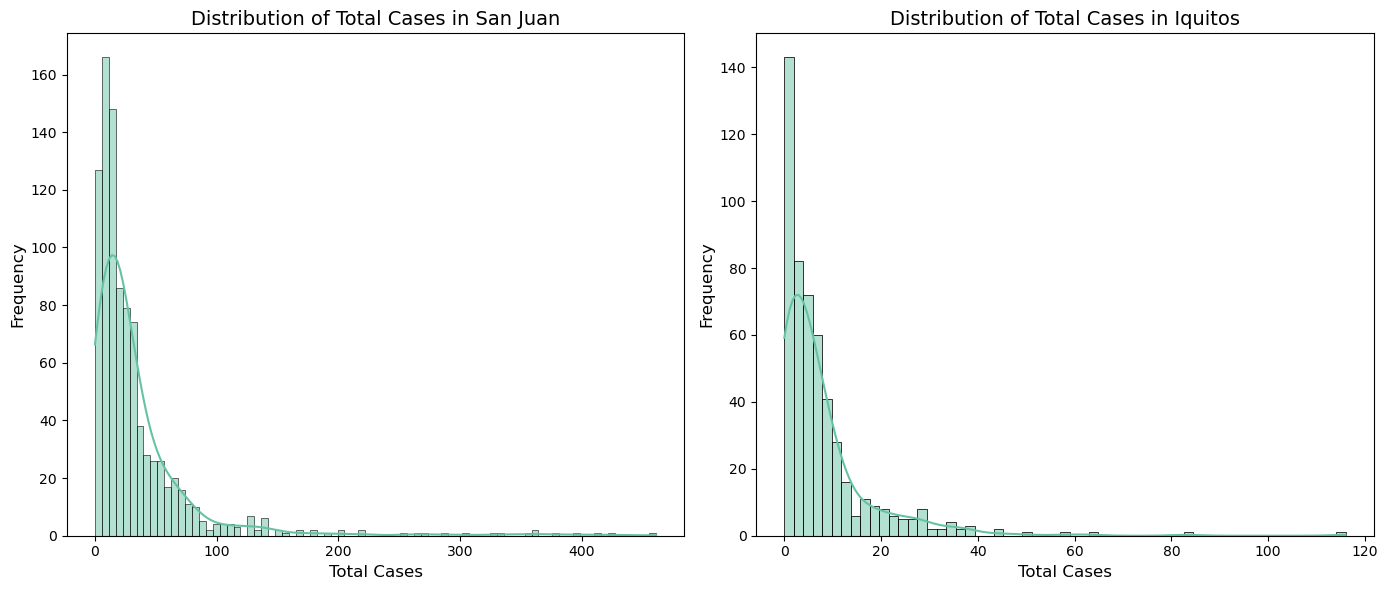

In [55]:
# plotting target variable distribution
plt.figure(figsize=(14,6))

plt.subplot(1, 2, 1)
sns.histplot(train_df[train_df['city'] == 'sj']['total_cases'], kde=True)
plt.title("Distribution of Total Cases in San Juan")
plt.xlabel("Total Cases")
plt.ylabel("Frequency")

plt.subplot(1, 2, 2)
sns.histplot(train_df[train_df['city'] == 'iq']['total_cases'], kde=True)
plt.title("Distribution of Total Cases in Iquitos")
plt.xlabel("Total Cases")
plt.ylabel("Frequency")

plt.tight_layout()
plt.savefig('total_cases_distribution.png')

### Missing Value Analysis

In [57]:
# Calculate missing values percentage
missing_percentage = (train_df.isnull().sum() / len(train_df)) * 100
missing_data = pd.DataFrame({
    "Missing values": train_df.isnull().sum(),
    "Percentage (%)": missing_percentage
})

missing_data = missing_data.sort_values('Percentage (%)', ascending=False)
print("\nMissing values analysis:")
print(missing_data[missing_data['Missing values'] > 0])


Missing values analysis:
                                       Missing values  Percentage (%)
ndvi_ne                                           194       13.324176
ndvi_nw                                            52        3.571429
station_diur_temp_rng_c                            43        2.953297
station_avg_temp_c                                 43        2.953297
ndvi_sw                                            22        1.510989
ndvi_se                                            22        1.510989
station_precip_mm                                  22        1.510989
station_max_temp_c                                 20        1.373626
station_min_temp_c                                 14        0.961538
reanalysis_sat_precip_amt_mm                       13        0.892857
precipitation_amt_mm                               13        0.892857
reanalysis_relative_humidity_percent               10        0.686813
reanalysis_max_air_temp_k                          10        0.6

<Figure size 800x600 with 0 Axes>

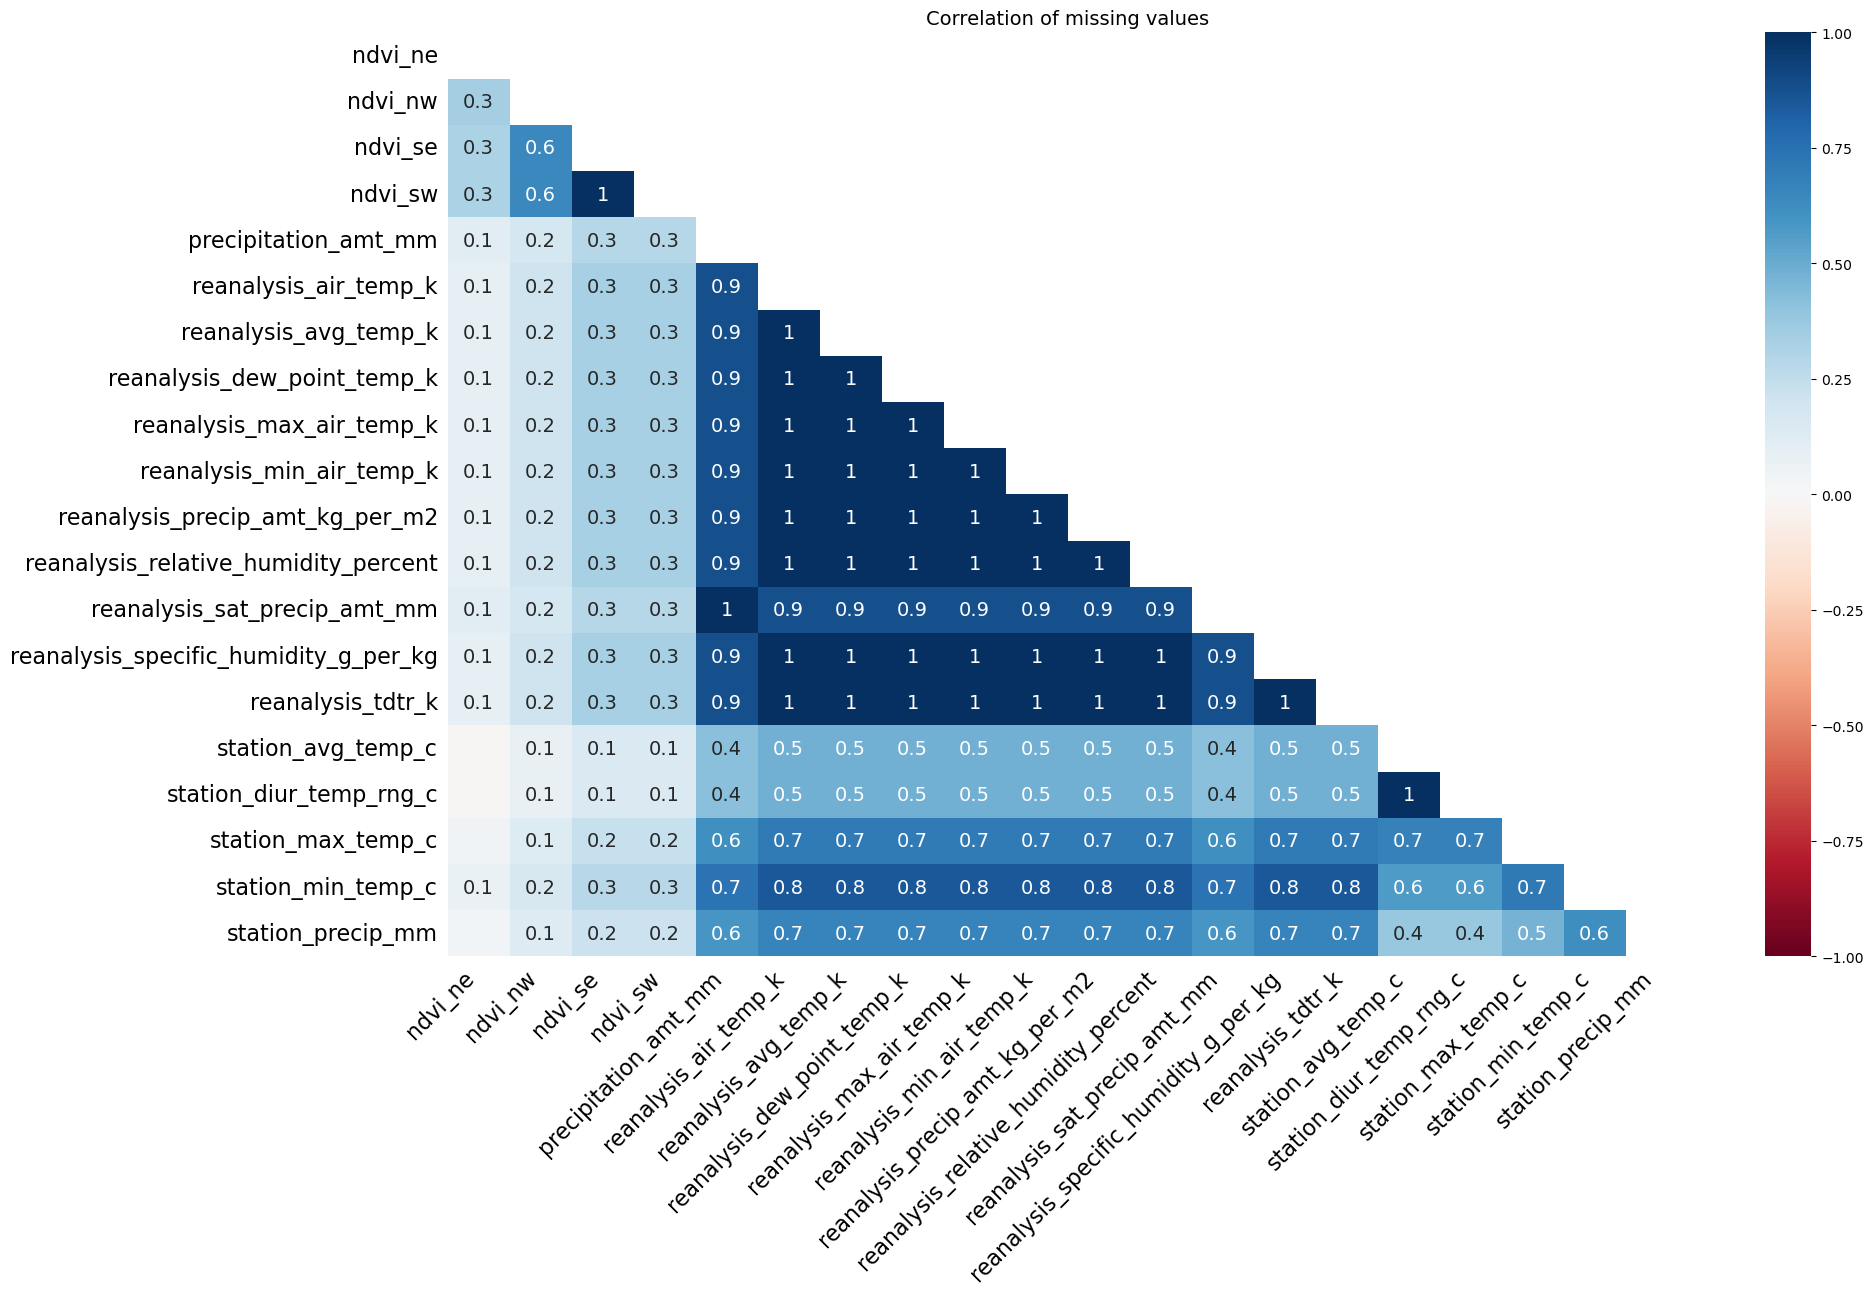

In [ ]:
# Plot missing values
plt.figure(figsize=(8, 6))
msno.heatmap(train_df)
plt.title("Correlation of missing values")
plt.savefig("_missing_values_heatmap.png");

In [61]:
# Set up time series data
sj_ts = train_df[train_df['city'] == 'sj'].sort_values('week_start_date')
iq_ts = train_df[train_df['city'] == 'iq'].sort_values('week_start_date')

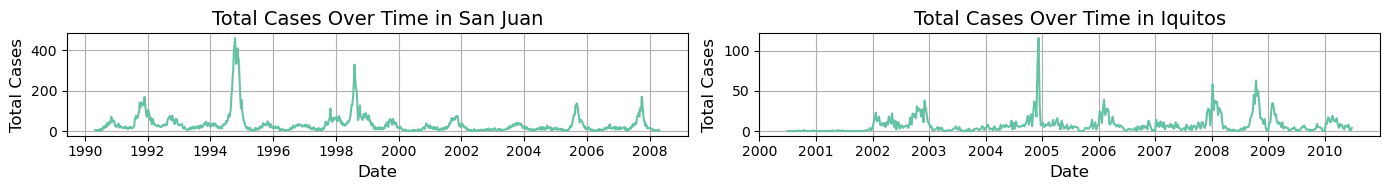

In [62]:
plt.figure(figsize=(14, 2))

plt.subplot(1, 2, 1)
plt.plot(sj_ts['week_start_date'], sj_ts['total_cases'])
plt.title('Total Cases Over Time in San Juan')
plt.xlabel('Date')
plt.ylabel('Total Cases')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(iq_ts['week_start_date'], iq_ts['total_cases'])
plt.title('Total Cases Over Time in Iquitos')
plt.xlabel('Date')
plt.ylabel('Total Cases')
plt.grid(True)

plt.tight_layout()
plt.savefig('total_cases_timeseries.png');

In [63]:
# Yearly and monthly patterns
# Group by year and week of year to see seasonal patterns
sj_yearly = sj_ts.groupby(['year', 'weekofyear'])['total_cases'].mean().reset_index()
sj_yearly_pivot = sj_yearly.pivot(index='weekofyear', columns='year', values='total_cases')

iq_yearly = iq_ts.groupby(['year', 'weekofyear'])['total_cases'].mean().reset_index()
iq_yearly_pivot = iq_yearly.pivot(index='weekofyear', columns='year', values='total_cases')

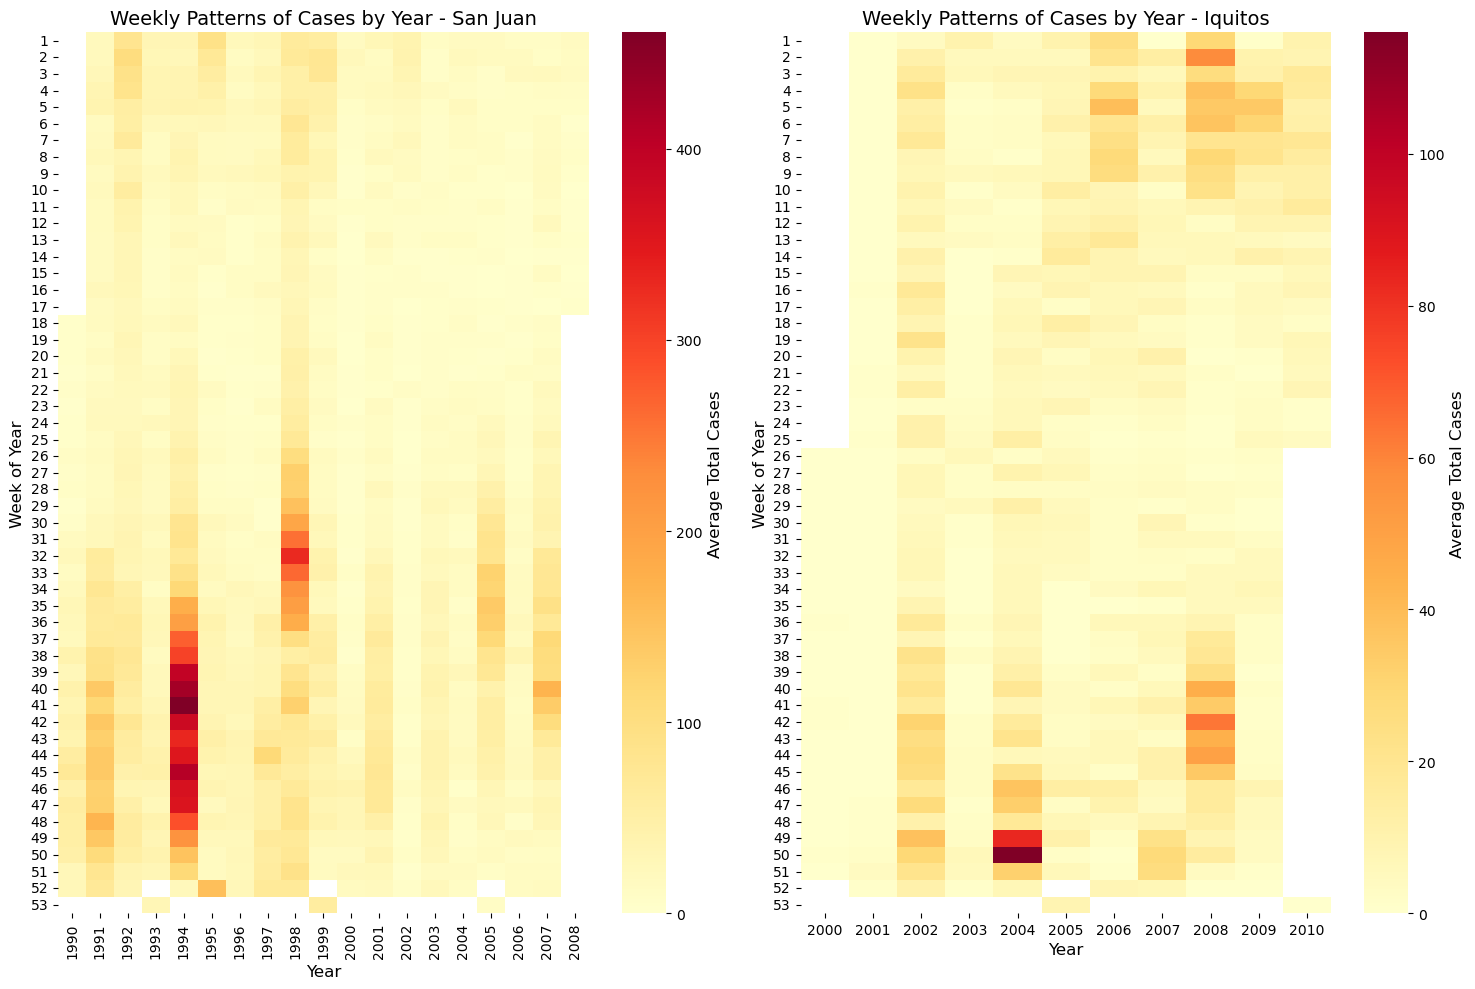

In [64]:
# plot yearly and monthly patterns
plt.figure(figsize=(15, 10))

plt.subplot(1, 2, 1)
sns.heatmap(sj_yearly_pivot, cmap='YlOrRd', cbar_kws={'label': 'Average Total Cases'})
plt.title("Weekly Patterns of Cases by Year - San Juan")
plt.xlabel("Year")
plt.ylabel("Week of Year")

plt.subplot(1, 2, 2)
sns.heatmap(iq_yearly_pivot, cmap='YlOrRd', cbar_kws={'label': 'Average Total Cases'})
plt.title("Weekly Patterns of Cases by Year - Iquitos")
plt.xlabel("Year")
plt.ylabel("Week of Year")

plt.tight_layout()
plt.savefig('weekly_patterns_heatmap.png');


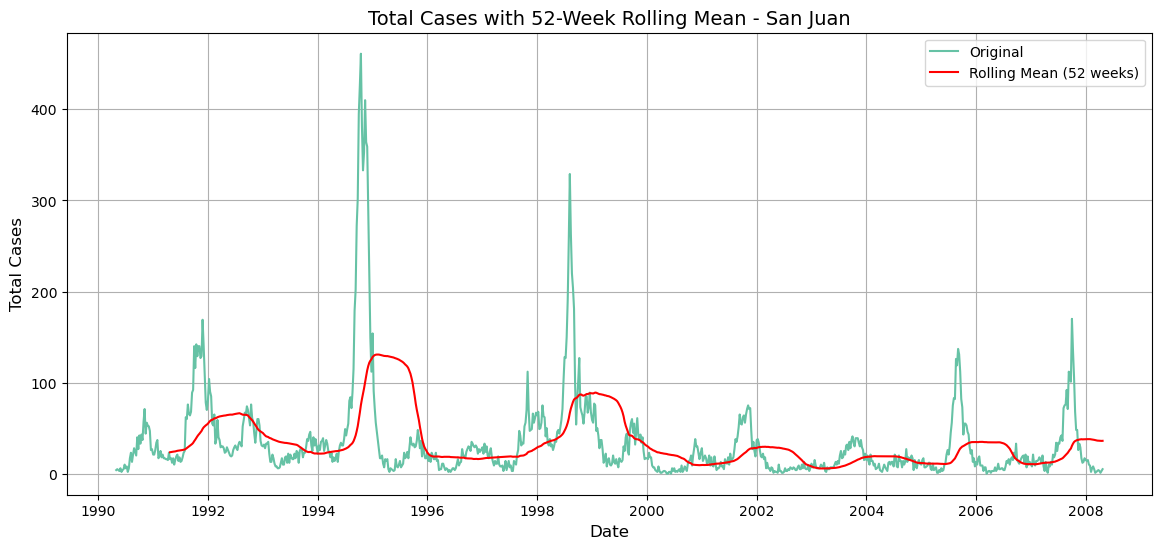

In [66]:
# Calculate rolling statistics for San Juan

if len(sj_ts) > 52:
    sj_rolling = sj_ts.set_index('week_start_date')["total_cases"].rolling(window=52).mean()

    plt.figure(figsize=(14, 6))
    plt.plot(sj_ts['week_start_date'], sj_ts['total_cases'], label='Original')
    plt.plot(sj_rolling.index, sj_rolling.values, label='Rolling Mean (52 weeks)', color='red')
    plt.title('Total Cases with 52-Week Rolling Mean - San Juan')
    plt.xlabel('Date')
    plt.ylabel('Total Cases')
    plt.legend()
    plt.grid(True)
    plt.savefig('sj_rolling_mean.png');

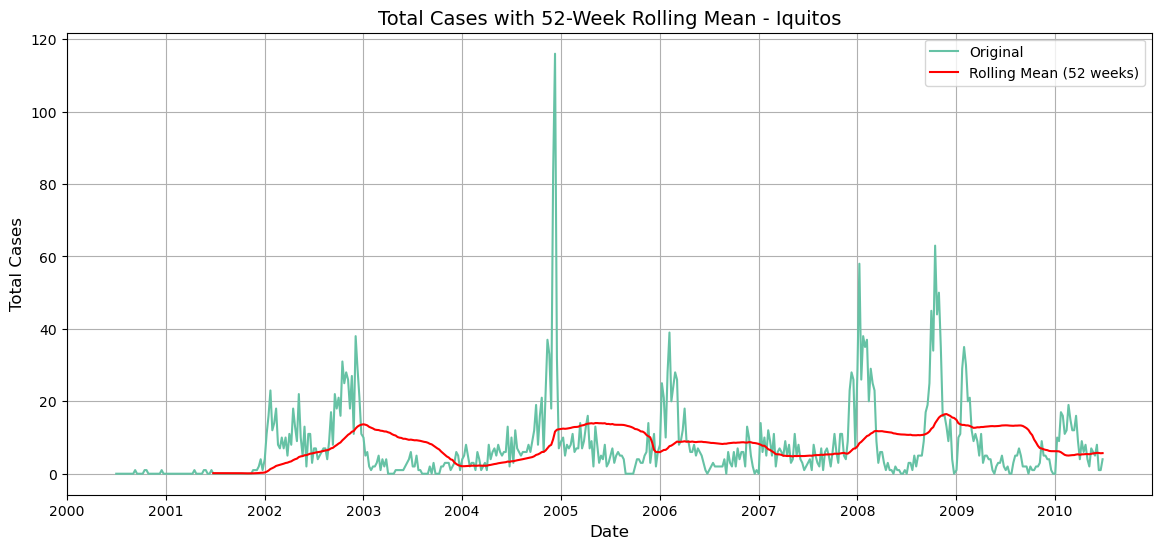

In [87]:
# calculate the rolling statistics for Iquitos

if len(iq_ts) > 52:
    iq_rolling = iq_ts.set_index('week_start_date')["total_cases"].rolling(window=52).mean()

    plt.figure(figsize=(14, 6))
    plt.plot(iq_ts['week_start_date'], iq_ts['total_cases'], label='Original')
    plt.plot(iq_rolling.index, iq_rolling.values, label='Rolling Mean (52 weeks)', color='red')
    plt.title('Total Cases with 52-Week Rolling Mean - Iquitos')
    plt.xlabel('Date')
    plt.ylabel('Total Cases')
    plt.legend()
    plt.grid(True)
    plt.savefig('iq_rolling_mean.png');

In [68]:
# Select numeric features for analysis
numeric_features = train_df.select_dtypes(include=[np.number]).columns.to_list()
numeric_features.remove('total_cases')
numeric_features.remove('year')
numeric_features.remove('weekofyear')

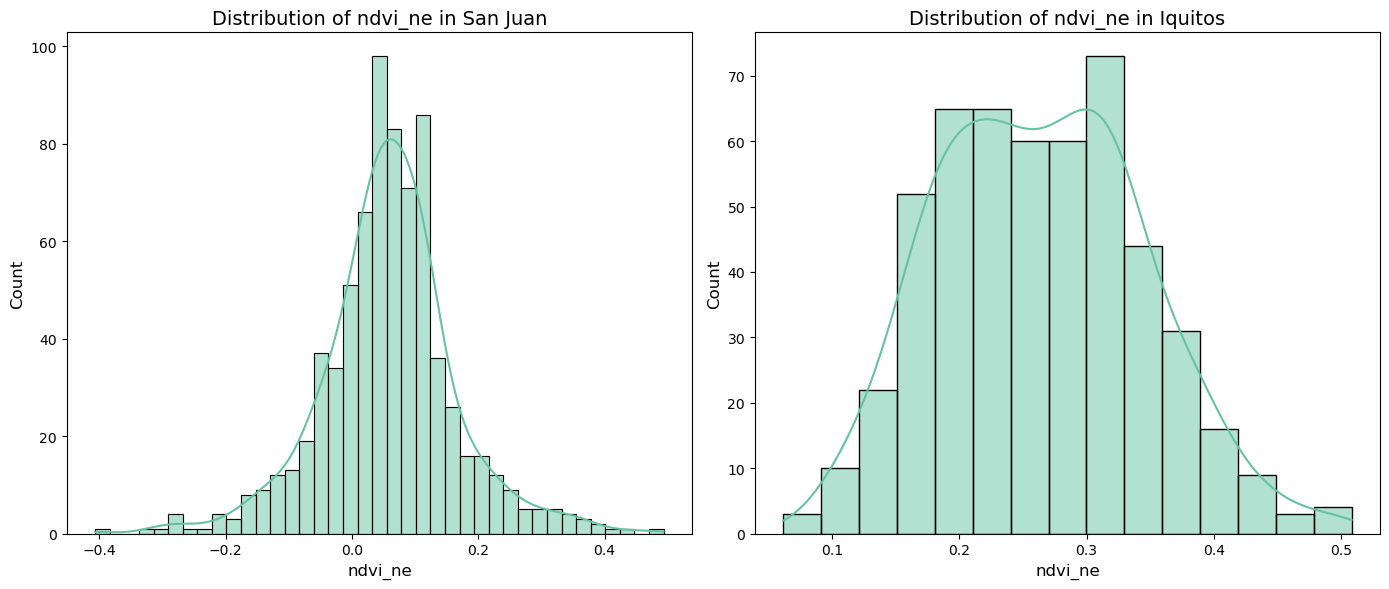

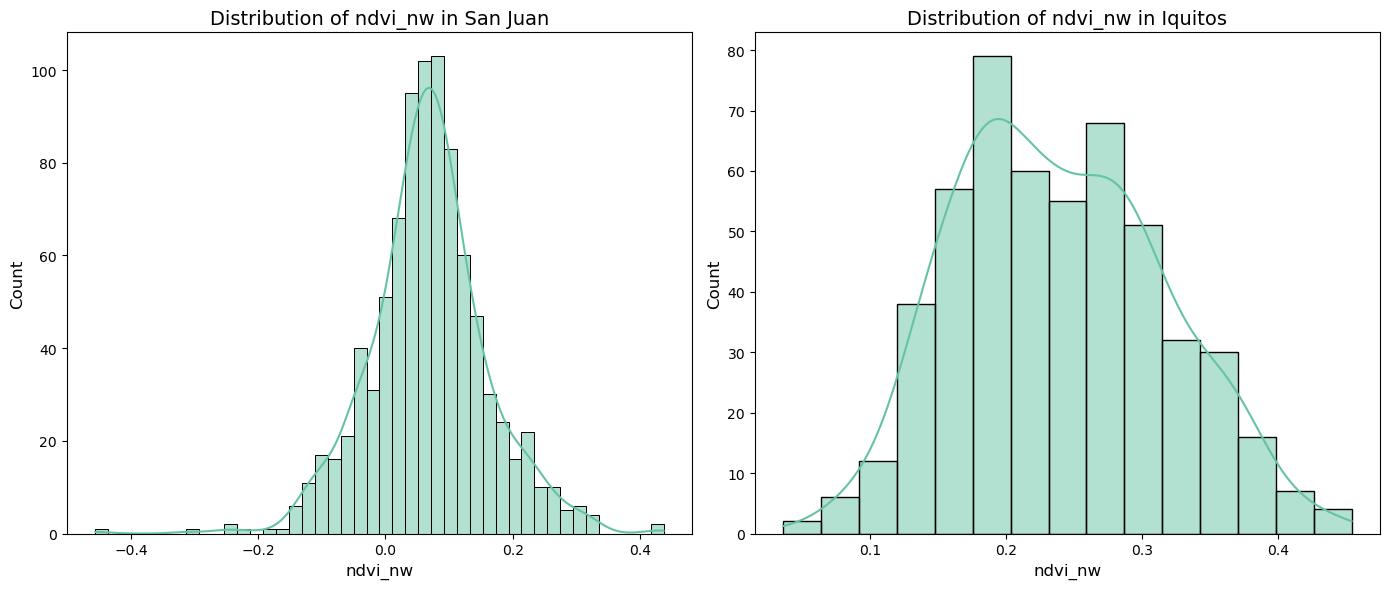

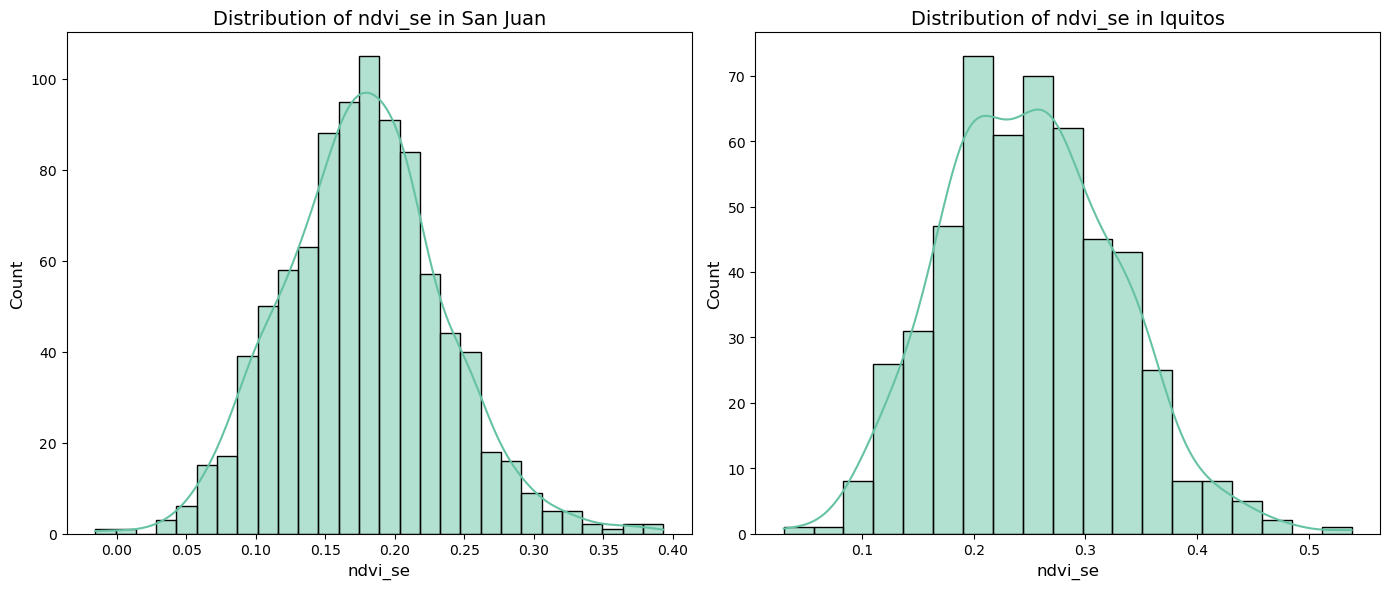

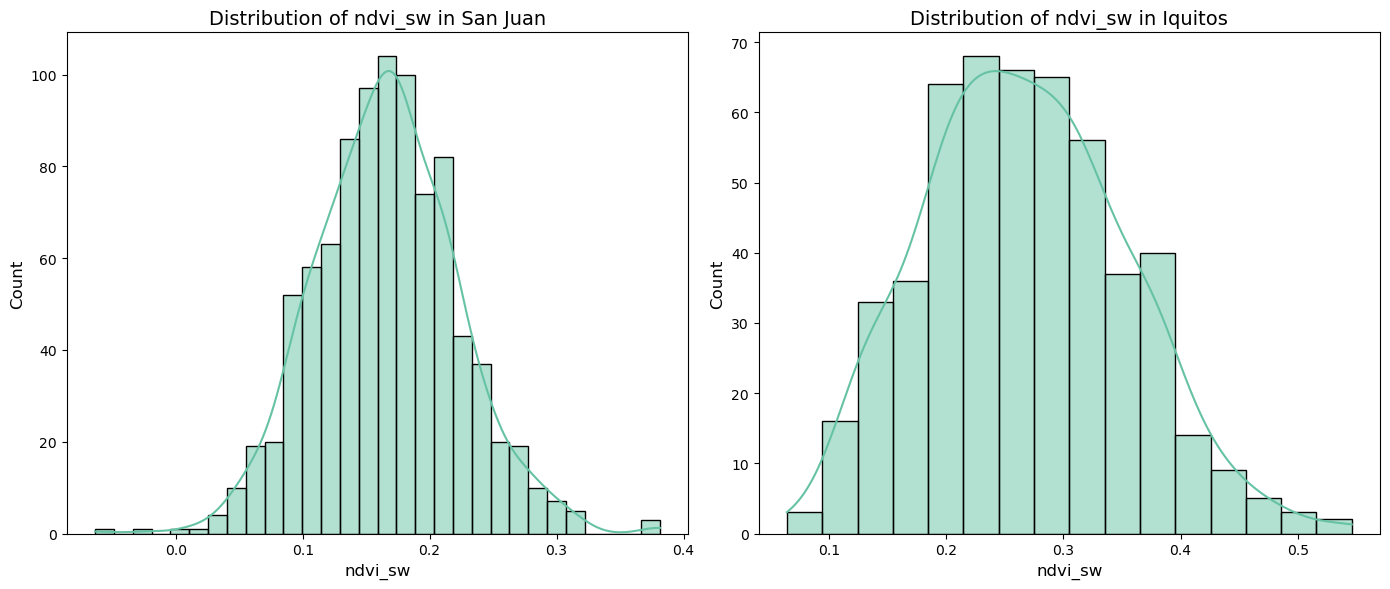

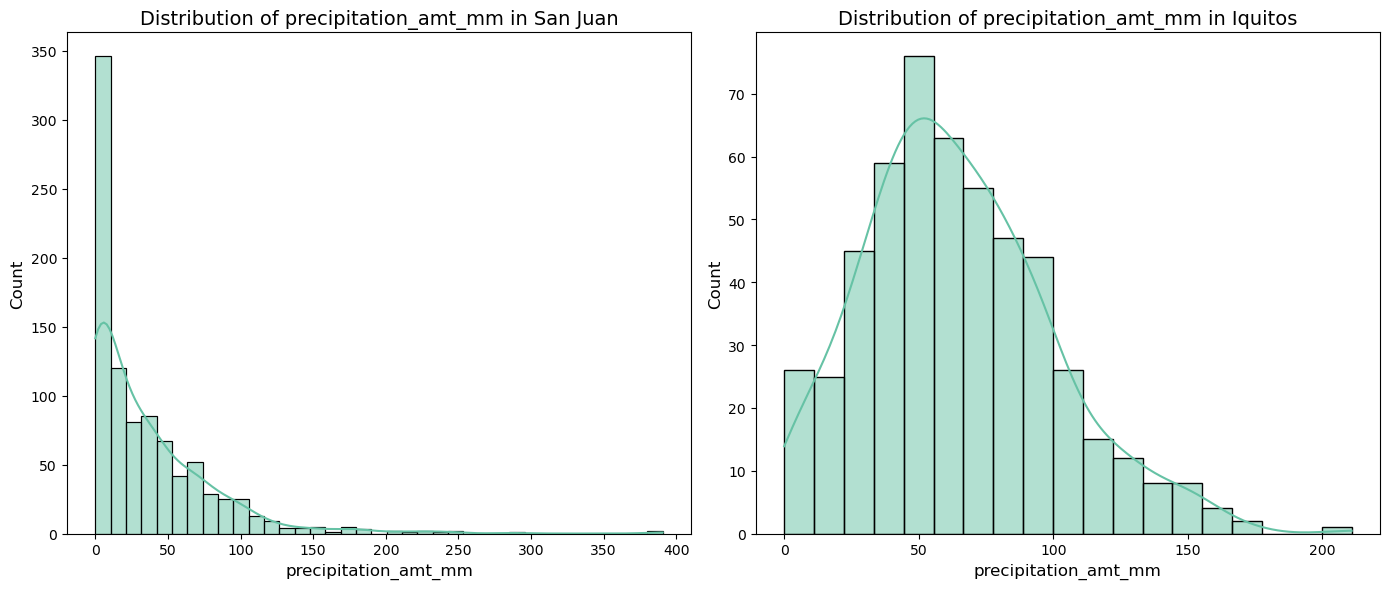

In [ ]:
# Create histograms for each numeric feature by city
for feature in numeric_features[:5]:
    plt.figure(figsize=(14, 6))
    
    plt.subplot(1, 2, 1)
    sns.histplot(train_df[train_df['city'] == 'sj'][feature].dropna(), kde=True)
    plt.title(f'Distribution of {feature} in San Juan')
    plt.xlabel(feature)
    
    plt.subplot(1, 2, 2)
    sns.histplot(train_df[train_df['city'] == 'iq'][feature].dropna(), kde=True)
    plt.title(f'Distribution of {feature} in Iquitos')
    plt.xlabel(feature)
    
    plt.tight_layout()
    plt.savefig(f'{feature}_distribution.png');

#### Correlation Analysis

In [70]:
# Calculate correlations with target variable
correlation_with_target = {}
for city in ['sj', 'iq']:
    city_data = train_df[train_df['city'] == city]
    corr = city_data[numeric_features + ['total_cases']].corr()['total_cases'].sort_values(ascending=False)
    correlation_with_target[city] = corr

print("\nTop correlations with total_cases for San Juan:")
print(correlation_with_target['sj'].head(10))


Top correlations with total_cases for San Juan:
total_cases                              1.000000
reanalysis_specific_humidity_g_per_kg    0.207947
reanalysis_dew_point_temp_k              0.203774
station_avg_temp_c                       0.196617
reanalysis_max_air_temp_k                0.194532
station_max_temp_c                       0.189901
reanalysis_min_air_temp_k                0.187943
reanalysis_air_temp_k                    0.181917
station_min_temp_c                       0.177012
reanalysis_avg_temp_k                    0.175267
Name: total_cases, dtype: float64


In [71]:
print("\nTop correlations with total_cases for Iquitos:")
print(correlation_with_target['iq'].head(10))


Top correlations with total_cases for Iquitos:
total_cases                              1.000000
reanalysis_specific_humidity_g_per_kg    0.236476
reanalysis_dew_point_temp_k              0.230401
reanalysis_min_air_temp_k                0.214514
station_min_temp_c                       0.211702
reanalysis_relative_humidity_percent     0.130083
station_avg_temp_c                       0.113070
reanalysis_precip_amt_kg_per_m2          0.101171
reanalysis_air_temp_k                    0.097098
precipitation_amt_mm                     0.090171
Name: total_cases, dtype: float64


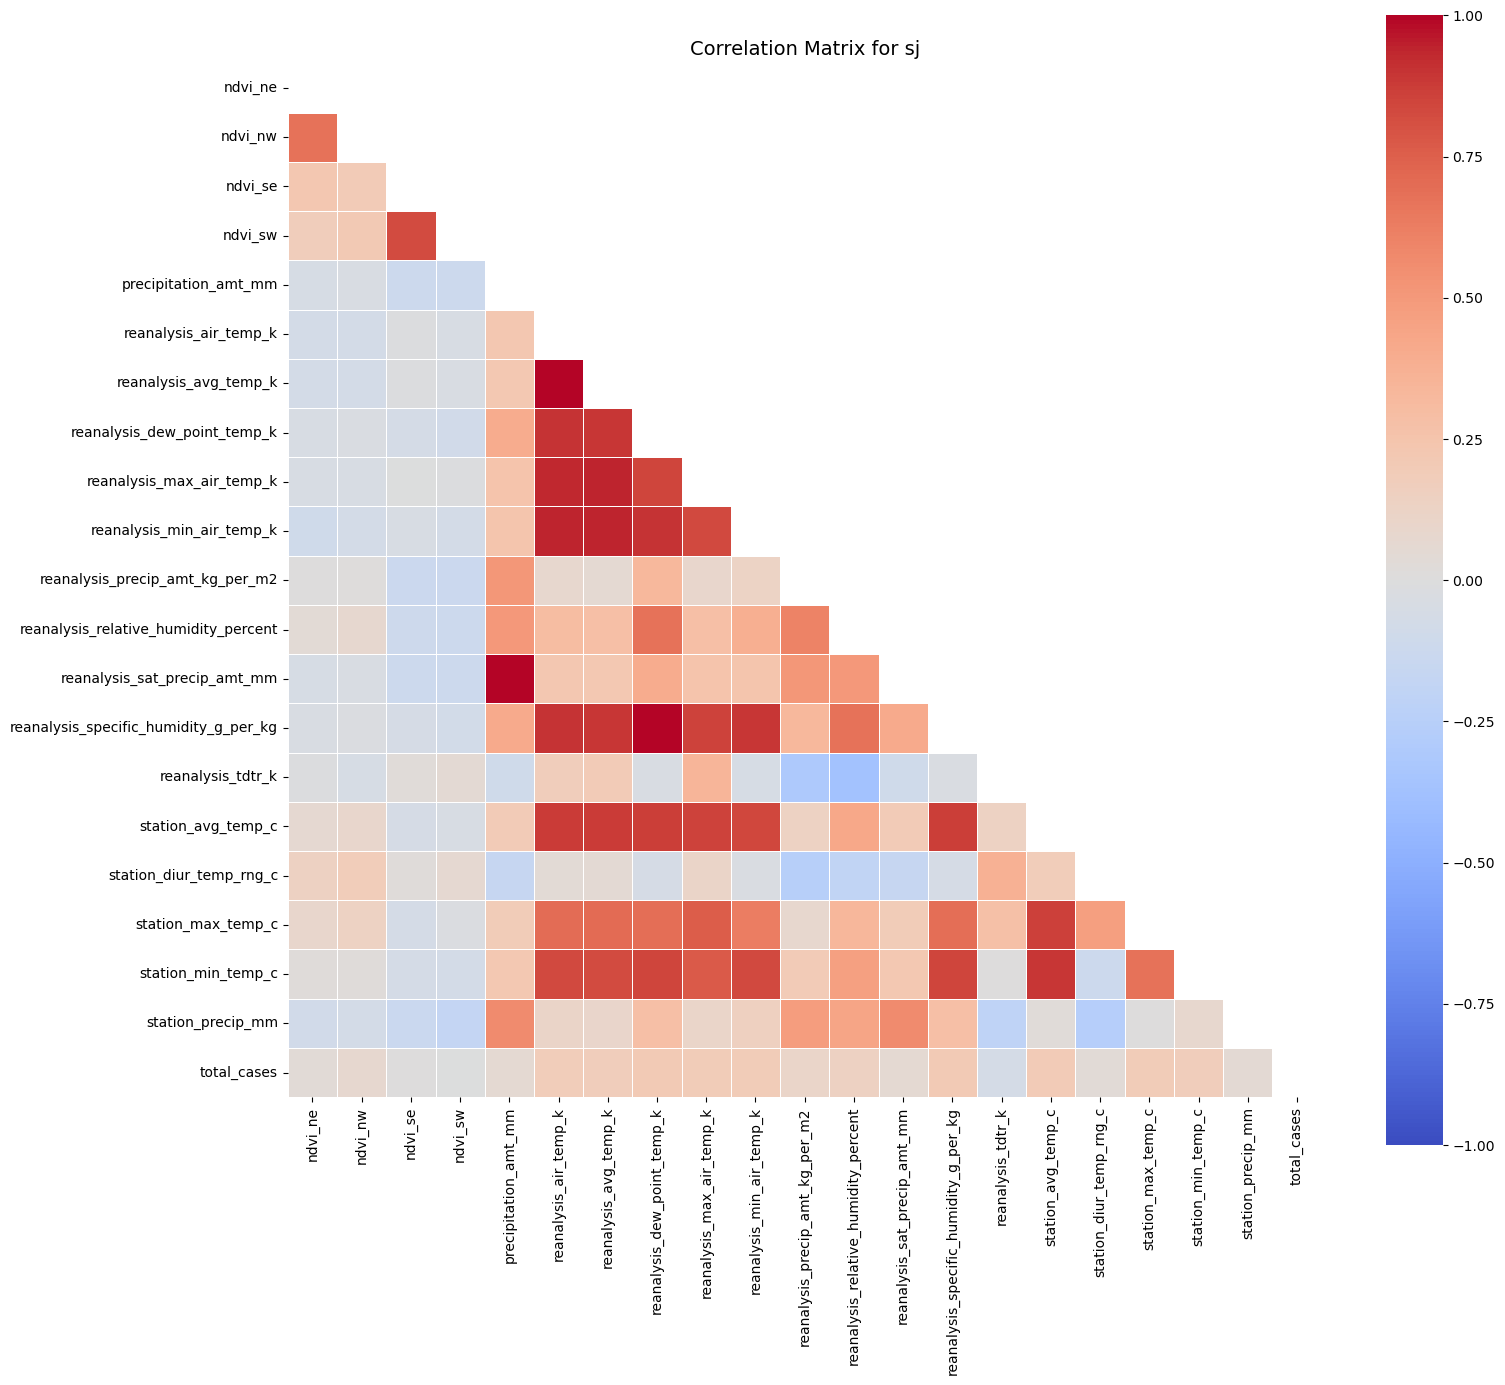

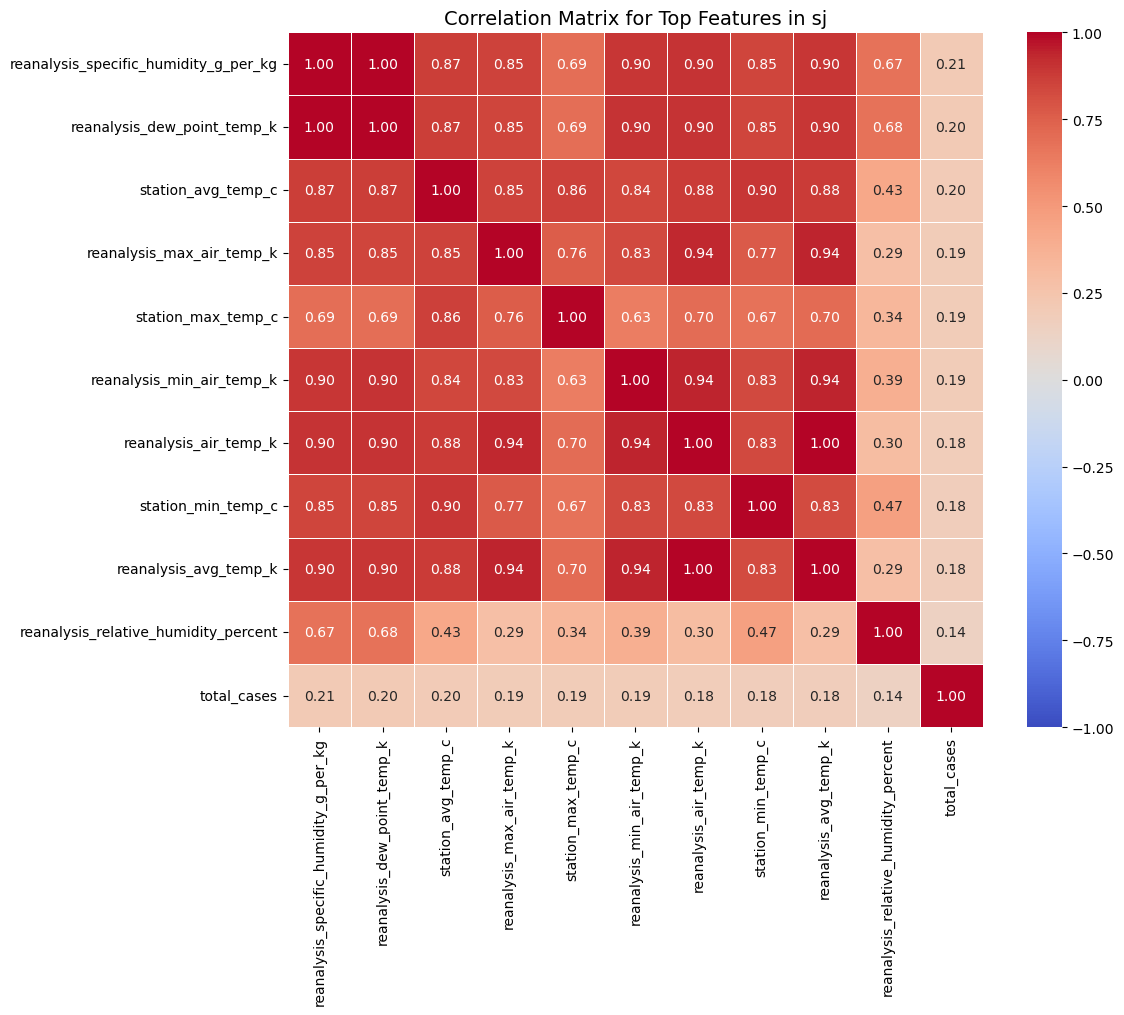

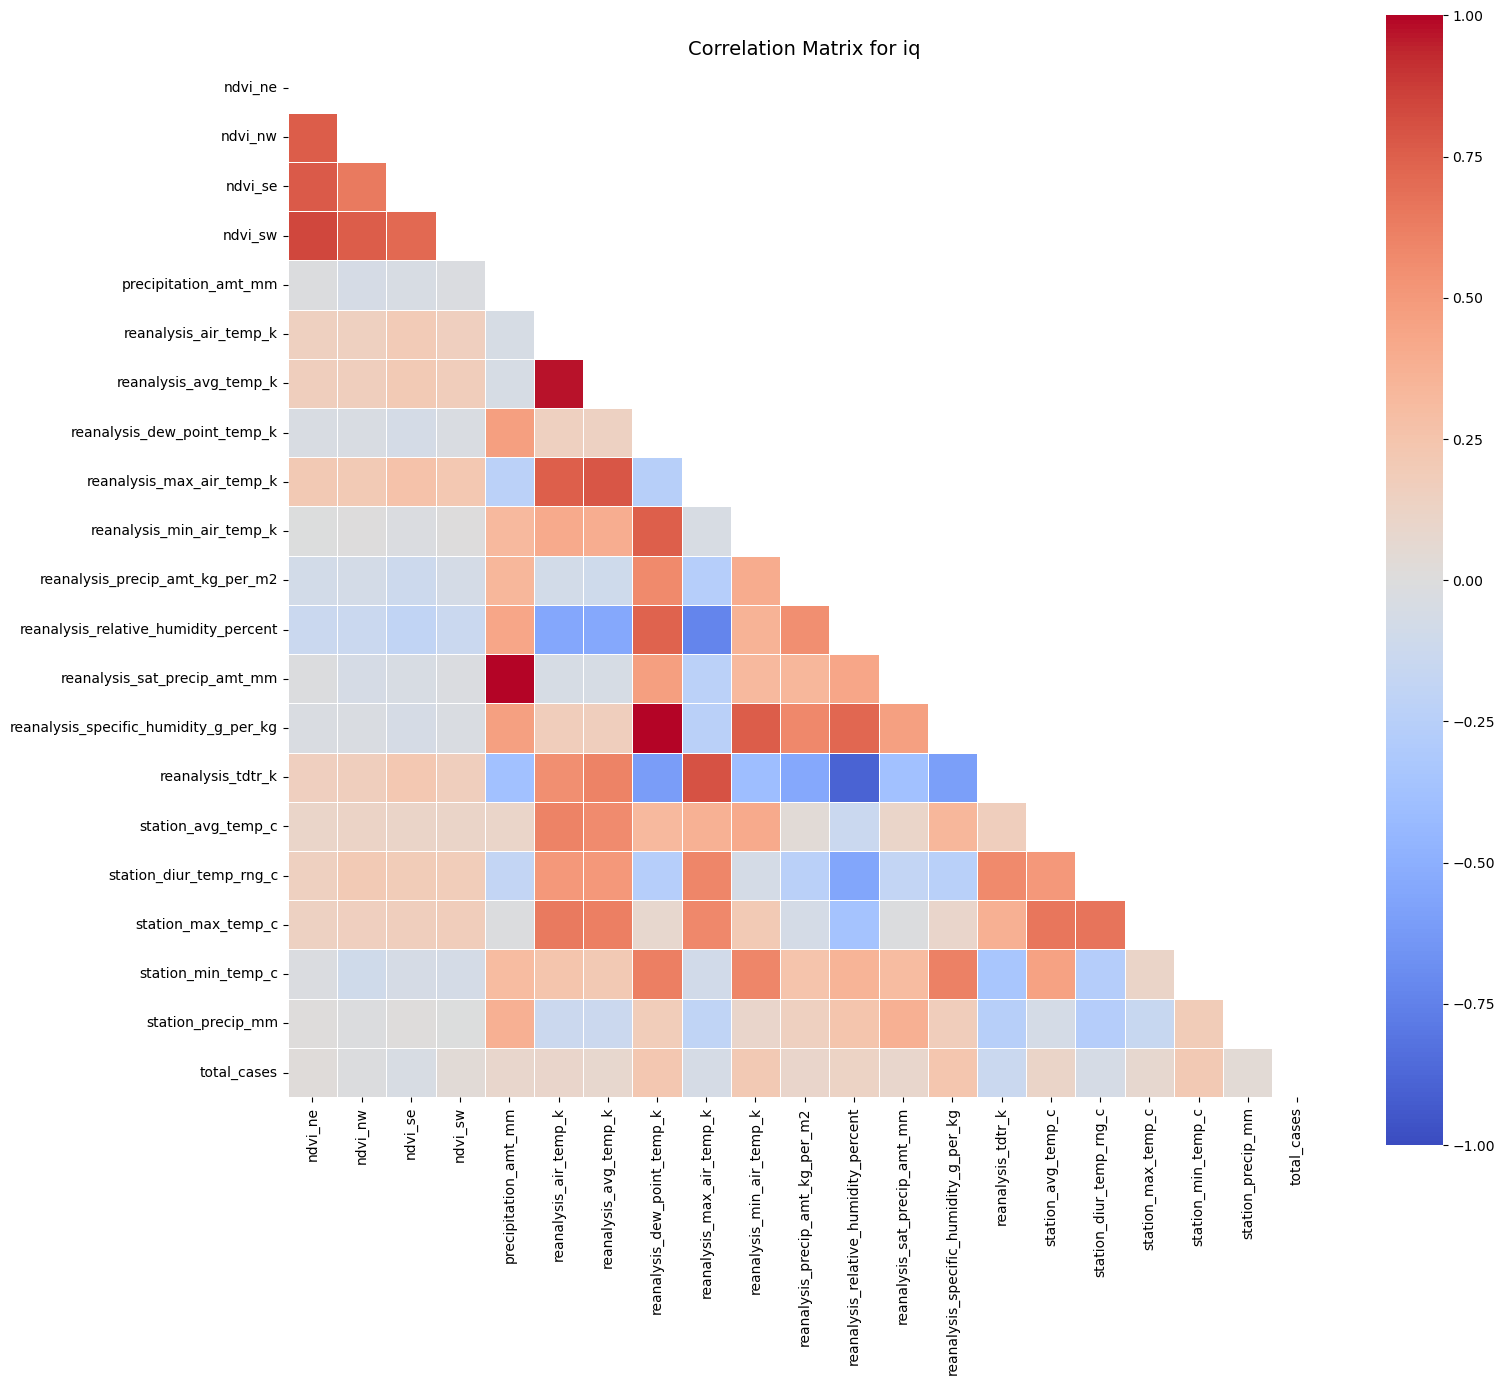

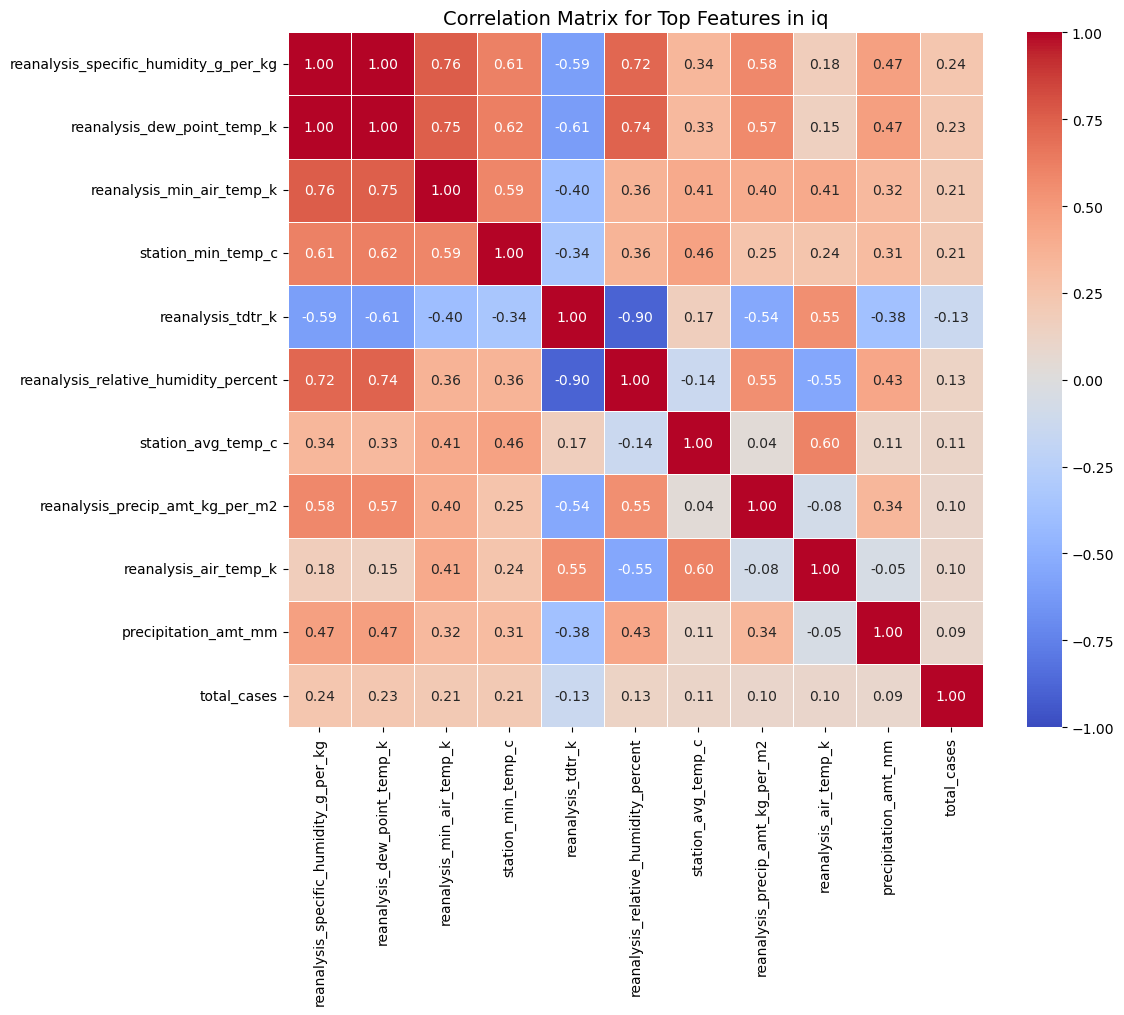

In [ ]:
# Create correlation heatmaps for each city
for city in ['sj', 'iq']:
    city_data = train_df[train_df['city'] == city]
    plt.figure(figsize=(16, 14))
    corr_matrix = city_data[numeric_features + ['total_cases']].corr()
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='coolwarm', 
                vmin=-1, vmax=1, center=0, square=True, linewidths=.5)
    plt.title(f'Correlation Matrix for {city}')
    plt.tight_layout()
    plt.savefig(f'{city}_correlation_matrix.png')

    top_features = correlation_with_target[city].drop('total_cases').abs().nlargest(10).index.tolist()
    plt.figure(figsize=(12, 10))
    focused_corr = city_data[top_features + ['total_cases']].corr()
    sns.heatmap(focused_corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, 
                center=0, square=True, linewidths=.5, fmt='.2f')
    plt.title(f'Correlation Matrix for Top Features in {city}')
    plt.tight_layout()
    plt.savefig(f'{city}_top_correlation_matrix.png');

#### Features Vs Target Analysis

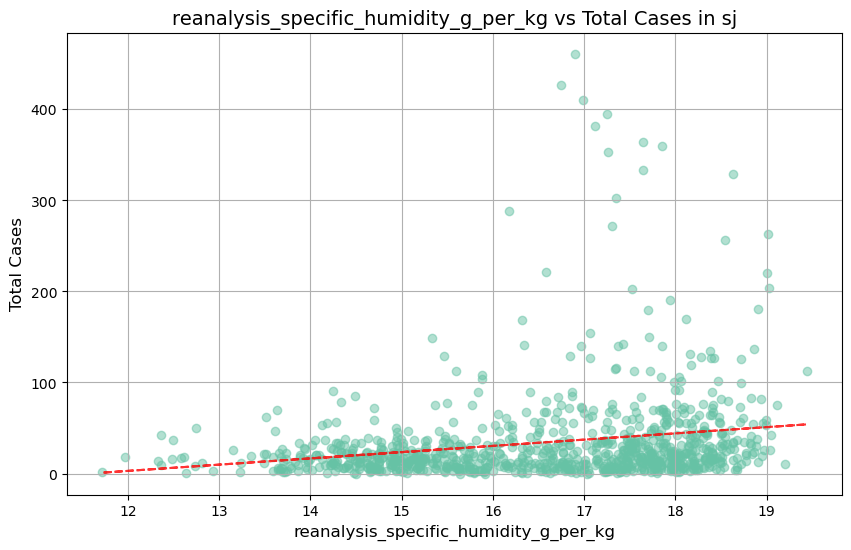

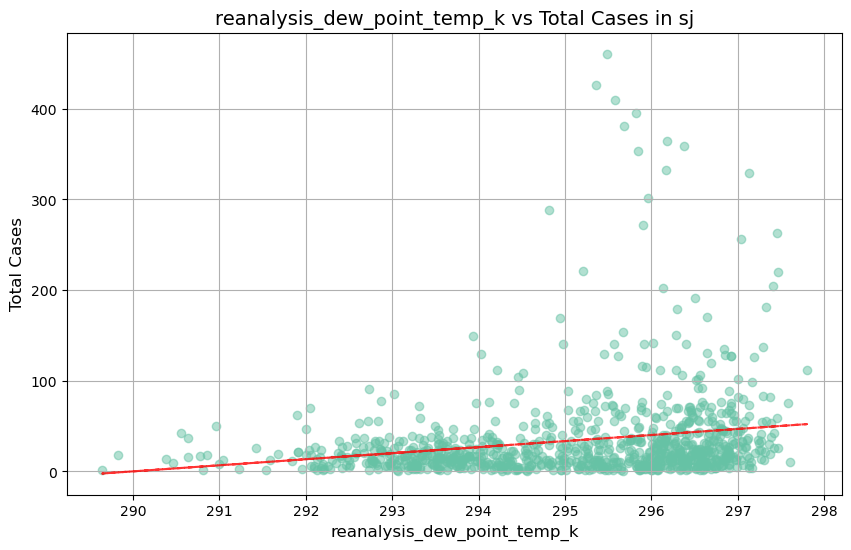

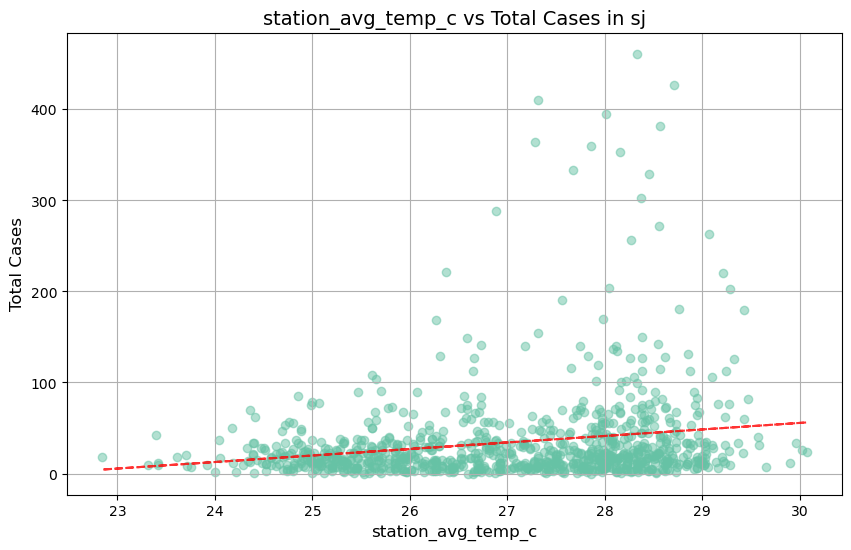

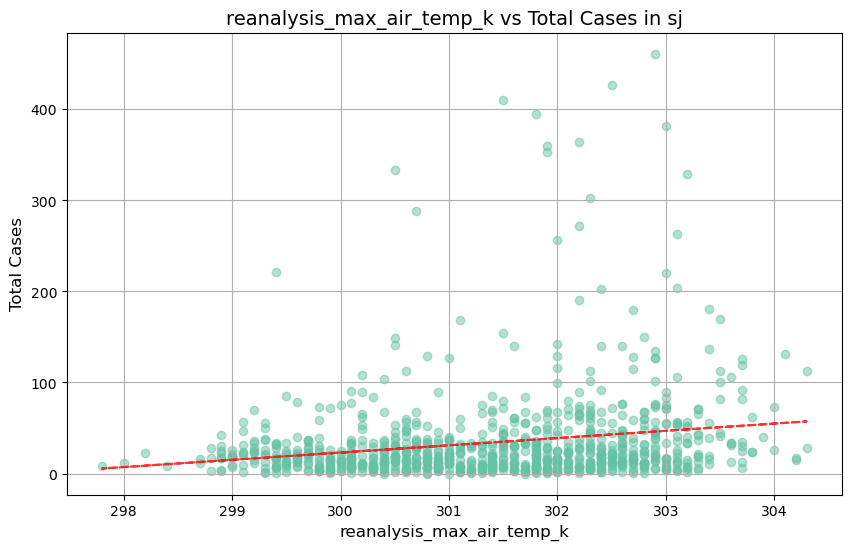

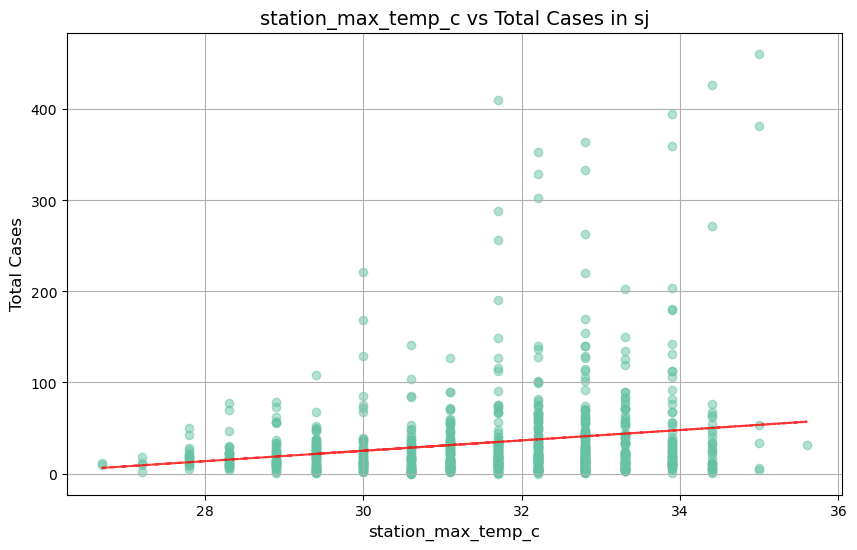

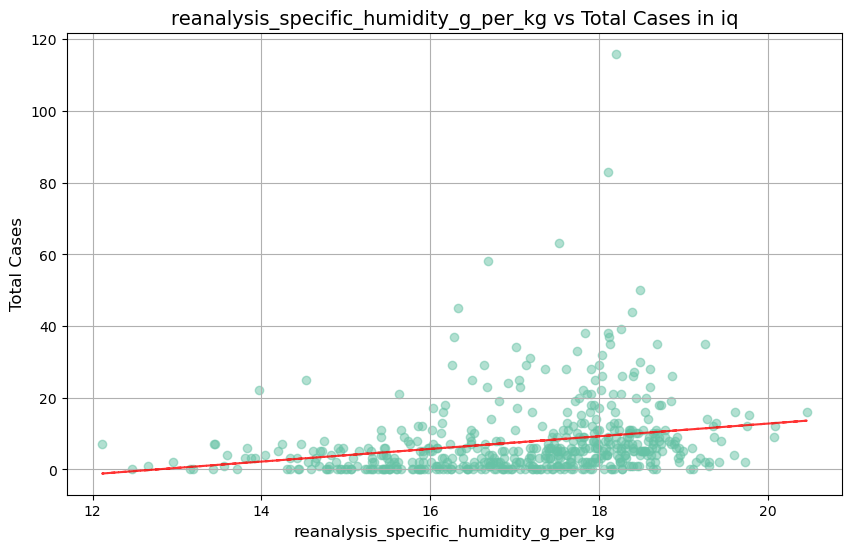

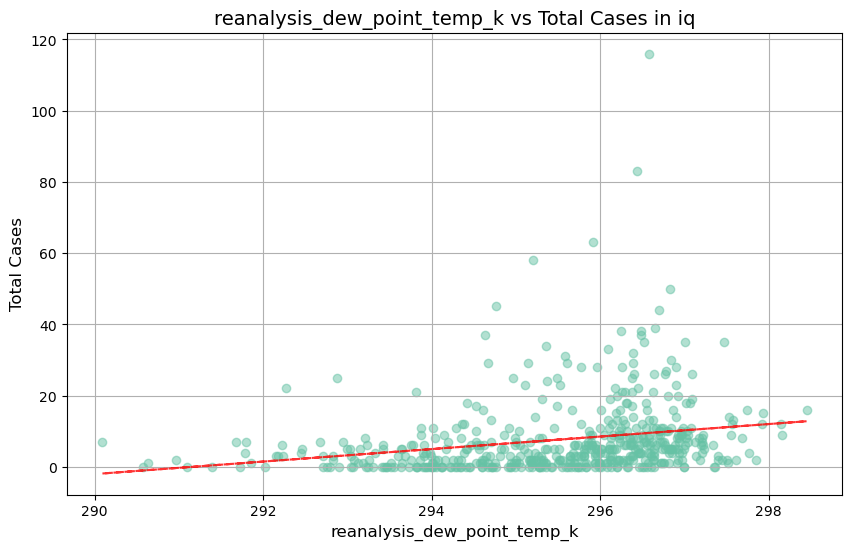

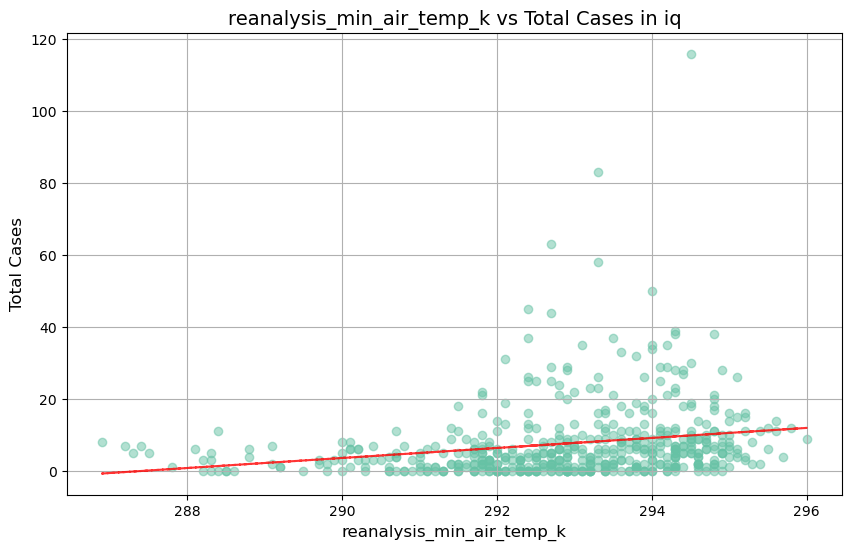

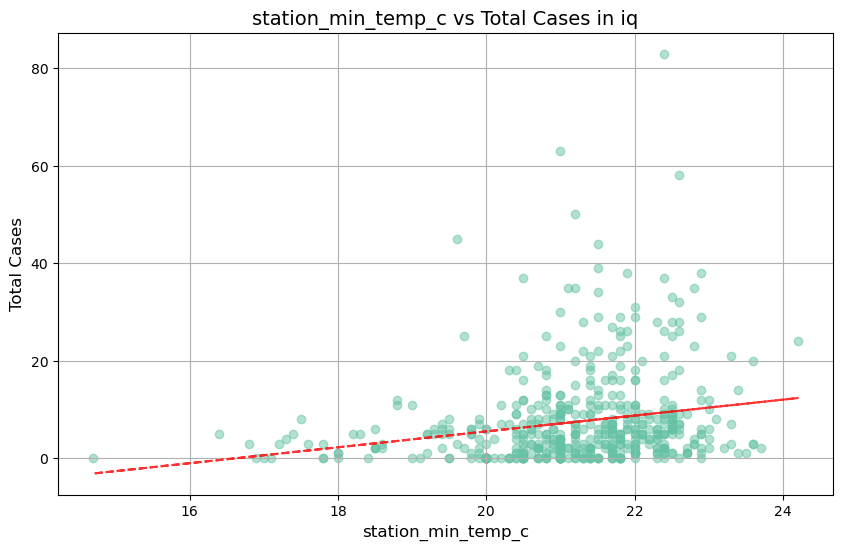

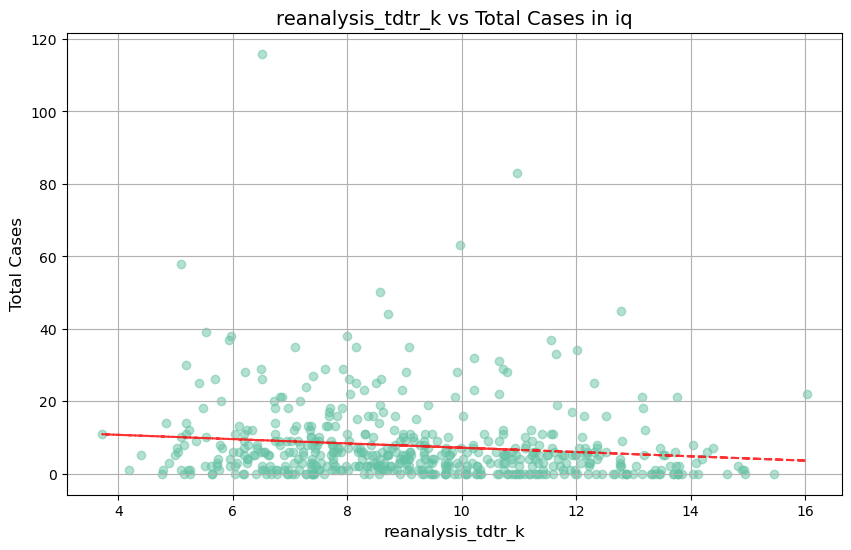

In [76]:
# Select top correlated features for each city
for city in ['sj', 'iq']:
    top_features = correlation_with_target[city].drop('total_cases').abs().nlargest(5).index.tolist()
    city_data = train_df[train_df['city'] == city]
    
    for feature in top_features:
        plt.figure(figsize=(10, 6))
        plt.scatter(city_data[feature], city_data['total_cases'], alpha=0.5)
        plt.title(f'{feature} vs Total Cases in {city}')
        plt.xlabel(feature)
        plt.ylabel('Total Cases')
        plt.grid(True)
        
        # Add trend line
        z = np.polyfit(city_data[feature].dropna(), city_data.loc[city_data[feature].dropna().index, 'total_cases'], 1)
        p = np.poly1d(z)
        plt.plot(city_data[feature].dropna(), p(city_data[feature].dropna()), "r--", alpha=0.8)
        
        plt.savefig(f'{city}_{feature}_vs_total_cases.png')

#### Seasonal Analysis

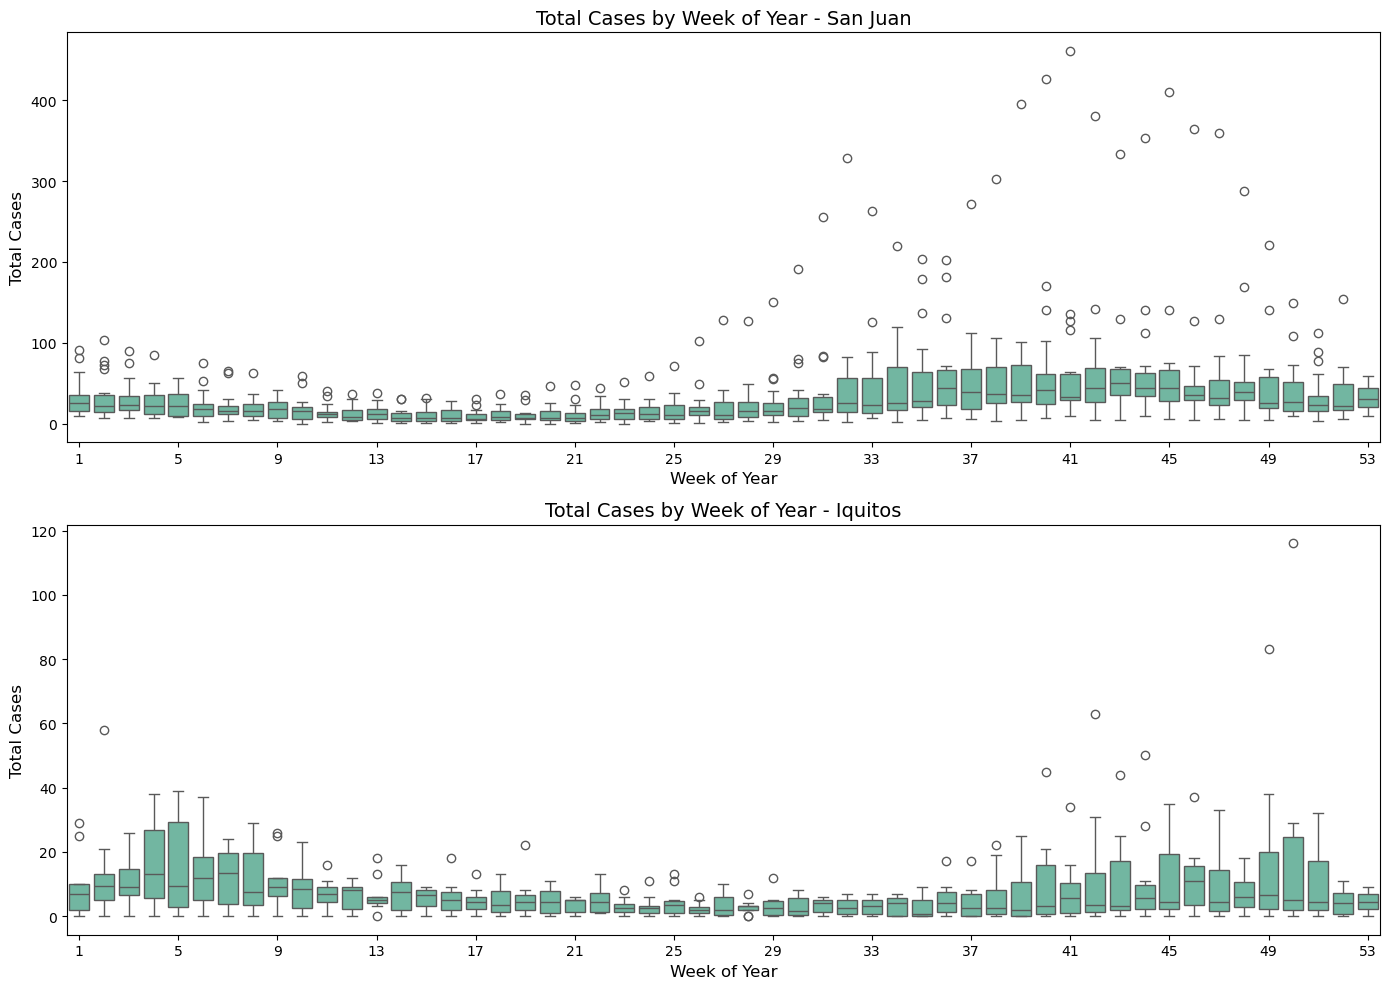

In [82]:
# Analyze seasonality by week of year
plt.figure(figsize=(14, 10))

plt.subplot(2, 1, 1)
sns.boxplot(x="weekofyear", y="total_cases", data=train_df[train_df["city"] == "sj"])
plt.title("Total Cases by Week of Year - San Juan")
plt.xlabel("Week of Year")
plt.ylabel("Total Cases")
plt.xticks(np.arange(0, 53, 4))

plt.subplot(2, 1, 2)
sns.boxplot(x="weekofyear", y="total_cases", data=train_df[train_df["city"] == "iq"])
plt.title("Total Cases by Week of Year - Iquitos")
plt.xlabel("Week of Year")
plt.ylabel("Total Cases")
plt.xticks(np.arange(0, 53, 4))

plt.tight_layout()
plt.savefig("seasonal_boxplot.png");

In [84]:
# Analyze how key climate variables change with week of year
key_climate_vars = ['station_avg_temp_c', 'station_precip_mm',
                   'reanalysis_relative_humidity_percent', 'reanalysis_specific_humidity_g_per_kg']

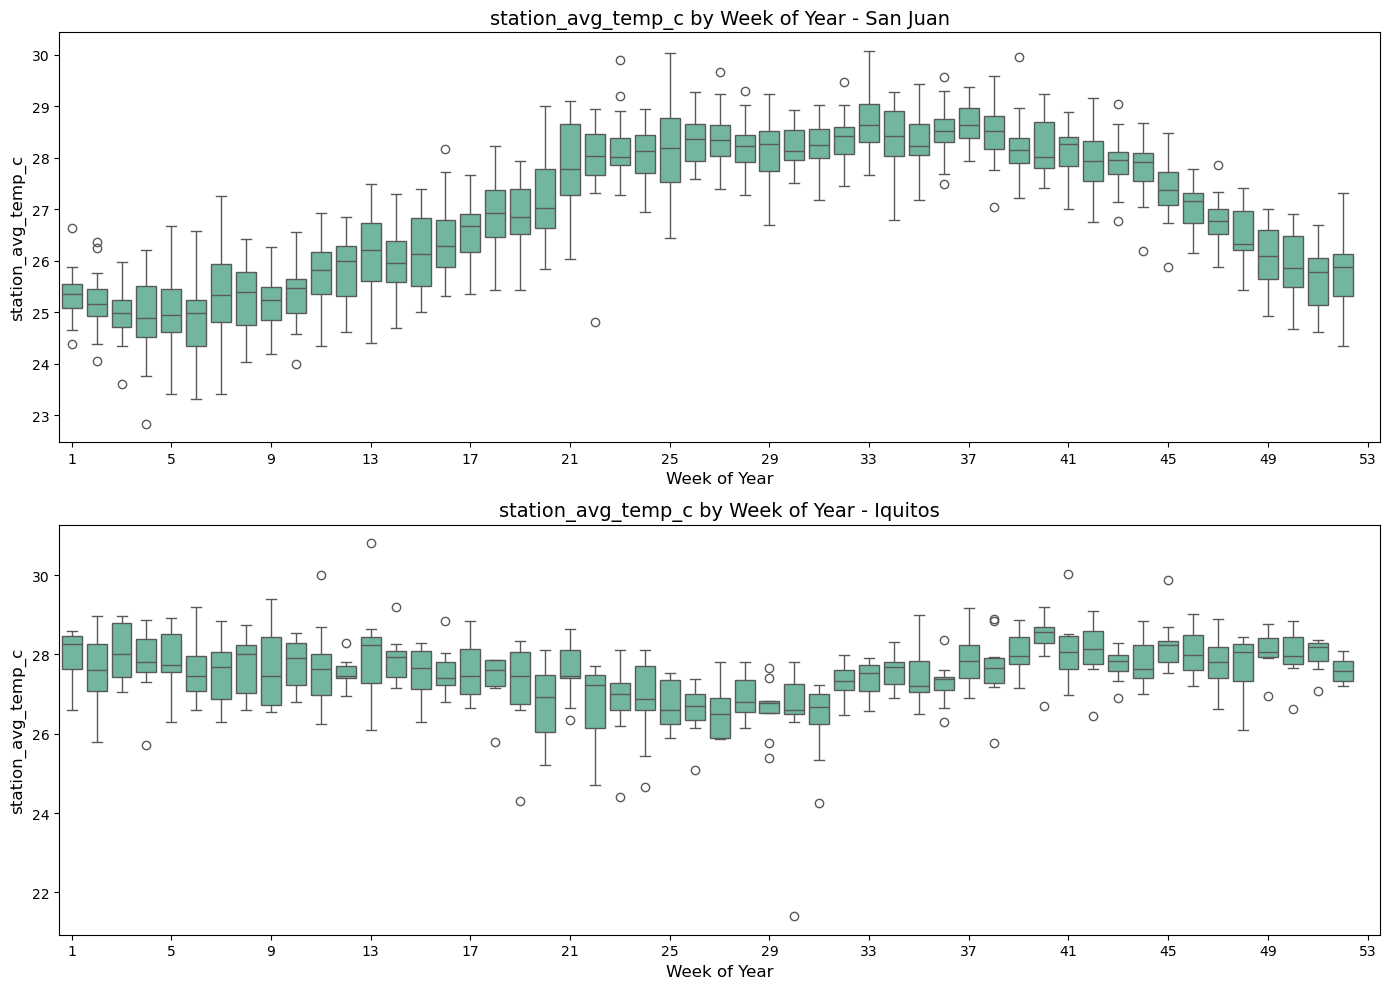

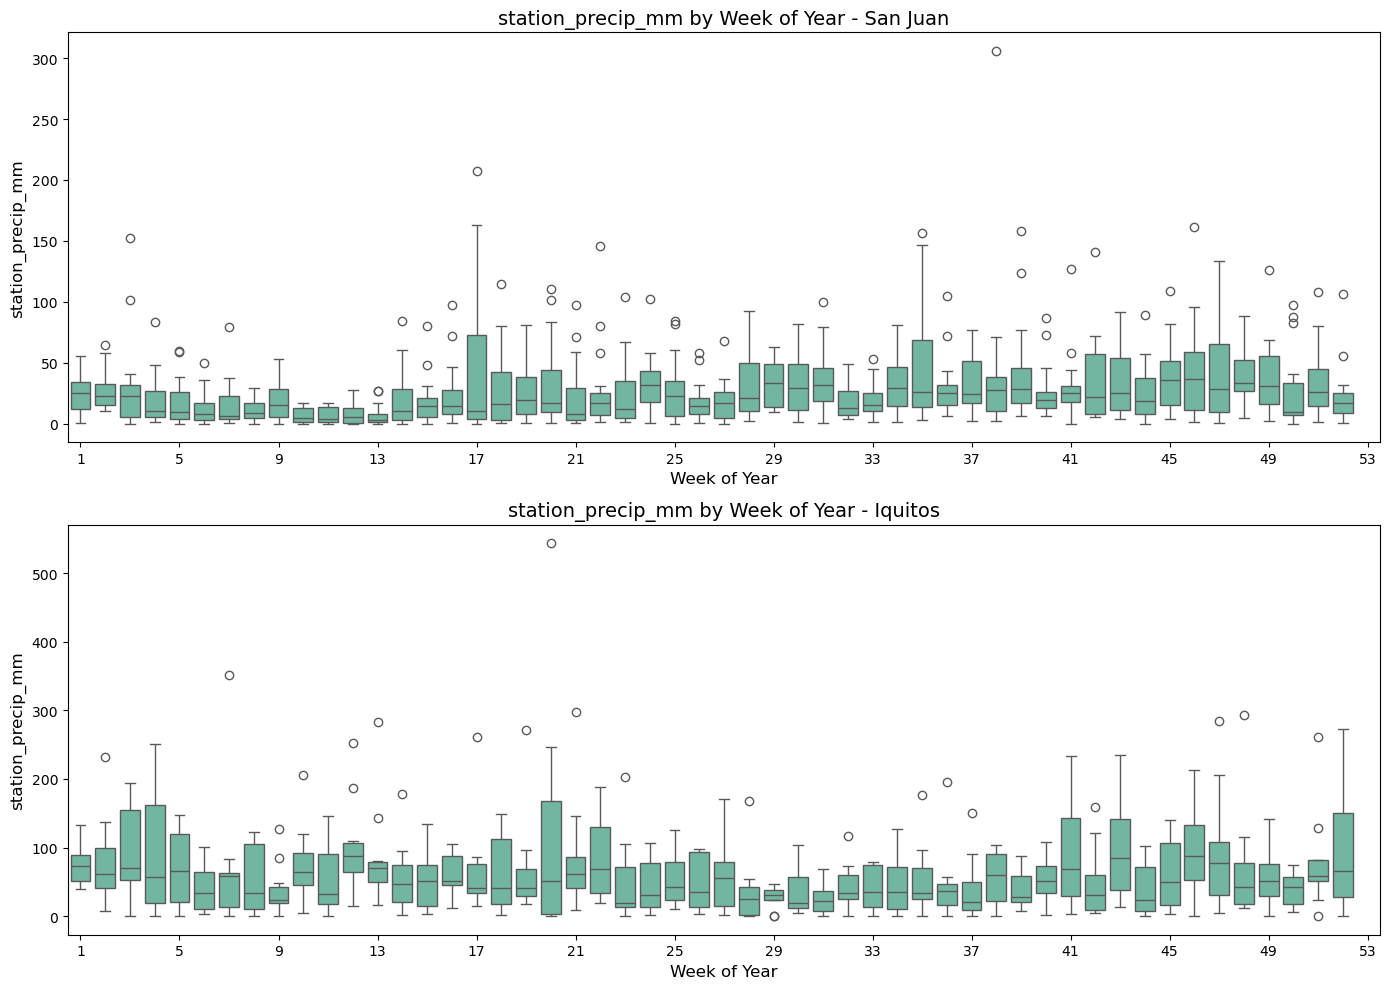

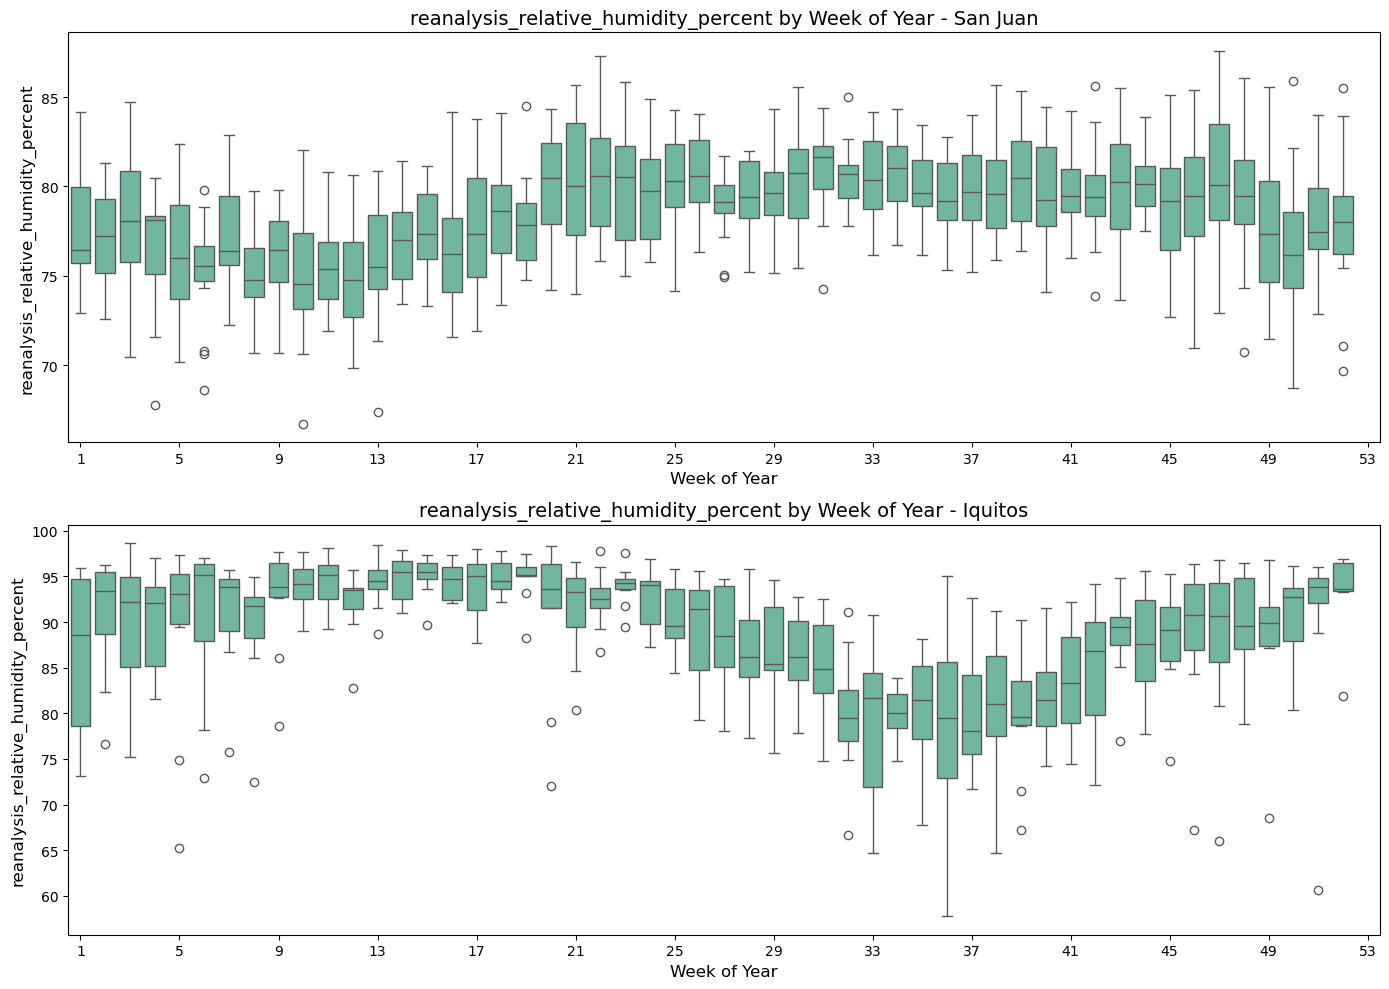

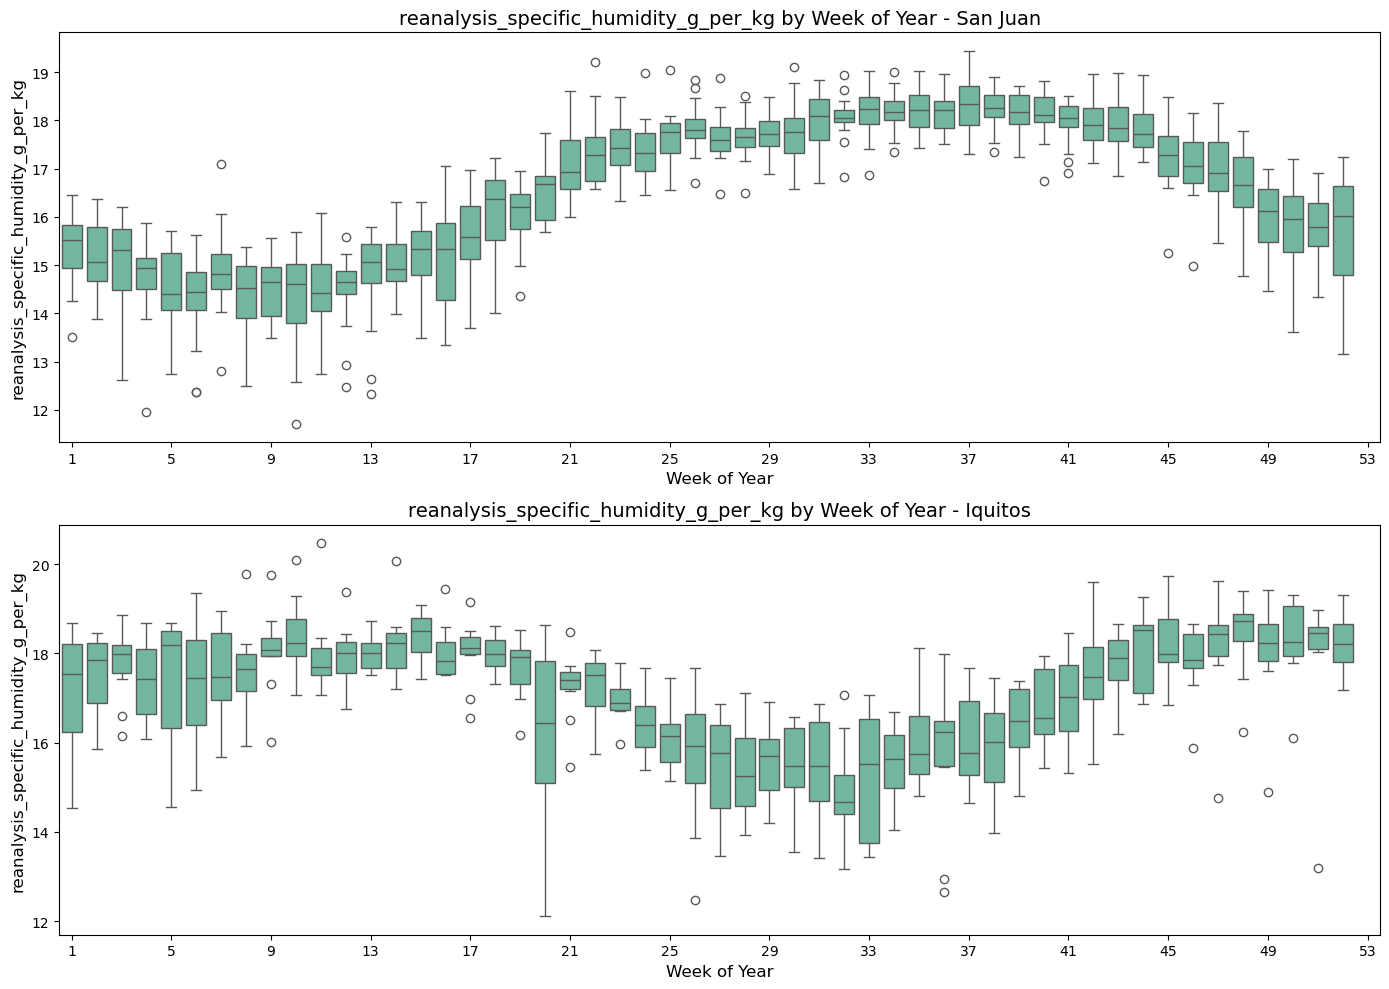

In [86]:
for var in key_climate_vars:
    plt.figure(figsize=(14, 10))
    
    plt.subplot(2, 1, 1)
    sns.boxplot(x='weekofyear', y=var, data=train_df[train_df['city'] == 'sj'])
    plt.title(f'{var} by Week of Year - San Juan')
    plt.xlabel('Week of Year')
    plt.ylabel(var)
    plt.xticks(np.arange(0, 53, 4))
    
    plt.subplot(2, 1, 2)
    sns.boxplot(x='weekofyear', y=var, data=train_df[train_df['city'] == 'iq'])
    plt.title(f'{var} by Week of Year - Iquitos')
    plt.xlabel('Week of Year')
    plt.ylabel(var)
    plt.xticks(np.arange(0, 53, 4))
    
    plt.tight_layout()
    plt.savefig(f'seasonal_{var}_boxplots.png')

Key EDA Findings:

1. Target Variable Distribution:
   - Both cities show highly skewed distributions of total_cases (skewed to the left)
   - San Juan generally has more cases than Iquitos

2. Missing Analysis:
   - There is no much missing values in the dataset
   - ndvi_ne is the one having more missing values (194) 13% followed by ndvi_nw at 52 missing values (3%)
   - The remaining dimensions have between 0.68% to 2.95% of missing data

3. Temporal Patterns:
   - There is no seasonal patterns in disease incidence
   - Evidence of year-to-year variations in seasonal patterns
   - Potential multi-year cycles in disease outbreaks
   - San Juan years start from 1990 to 2008 where as Iquitos starts from 2000 to 2010
   - 52-week Rolling statistics in both cities show the tendency of increase in the last weeks of the year

4. Climate Correlations:
   - Climate forecast system reanalysis variables show moderate correlation with total_cases in sj but not iq
   - Precipitation shows some correlation, but relationship may be complex

5. Missing Data:
   - Some features have missing values that need to be addressed
   - Missing patterns may differ between cities

6. City Differences:
   - The two cities show different baseline levels of disease
   - Climate variable distributions differ between locations
   - Correlation patterns with the target variable vary by city

7. Key Predictive Features:
   - Humidity variables appear strongly predictive
   - Temperature metrics show consistent relationships
   - NDVI (vegetation) variables may provide additional signal

8. Modeling Considerations:
   - Time series nature of the data requires careful validation approach
   - May benefit from separate models for each city
   - Likely need for feature engineering to capture lagged effects

9. The observations:
   - San Juan has 936 observations
   - Iquitos has 520 observations
   - The dataset has 1456 observations in total

### Data Preprocessing

#### Data Cleaning

In [89]:
# Copy the 'train_df' data
df = train_df.copy()
df.head()

,city,year,weekofyear,total_cases,week_start_date,ndvi_ne,ndvi_nw,ndvi_se,ndvi_sw,precipitation_amt_mm,reanalysis_air_temp_k,reanalysis_avg_temp_k,reanalysis_dew_point_temp_k,reanalysis_max_air_temp_k,reanalysis_min_air_temp_k,reanalysis_precip_amt_kg_per_m2,reanalysis_relative_humidity_percent,reanalysis_sat_precip_amt_mm,reanalysis_specific_humidity_g_per_kg,reanalysis_tdtr_k,station_avg_temp_c,station_diur_temp_rng_c,station_max_temp_c,station_min_temp_c,station_precip_mm
id,,,,,,,,,,,,,,,,,,,,,,,,,
1,sj,1990,18,4,1990-04-30,0.122600,0.103725,0.198483,0.177617,12.42,297.572857,297.742857,292.414286,299.8,295.9,32.00,73.365714,12.42,14.012857,2.628571,25.442857,6.900000,29.4,20.0,16.0
2,sj,1990,19,5,1990-05-07,0.169900,0.142175,0.162357,0.155486,22.82,298.211429,298.442857,293.951429,300.9,296.4,17.94,77.368571,22.82,15.372857,2.371429,26.714286,6.371429,31.7,22.2,8.6
3,sj,1990,20,4,1990-05-14,0.032250,0.172967,0.157200,0.170843,34.54,298.781429,298.878571,295.434286,300.5,297.3,26.10,82.052857,34.54,16.848571,2.300000,26.714286,6.485714,32.2,22.8,41.4
4,sj,1990,21,3,1990-05-21,0.128633,0.245067,0.227557,0.235886,15.36,298.987143,299.228571,295.310000,301.4,297.0,13.90,80.337143,15.36,16.672857,2.428571,27.471429,6.771429,33.3,23.3,4.0
5,sj,1990,22,6,1990-05-28,0.196200,0.262200,0.251200,0.247340,7.52,299.518571,299.664286,295.821429,301.9,297.5,12.20,80.460000,7.52,17.210000,3.014286,28.942857,9.371429,35.0,23.9,5.8


In [90]:
for city in ['sj', 'iq']:
    city_mask = df['city'] == city
    
    # For each NDVI direction with missing values
    for ndvi_dir in ['ndvi_ne', 'ndvi_nw', 'ndvi_se', 'ndvi_sw']:
        # Identify rows with missing values
        missing_mask = df[city_mask][ndvi_dir].isna()
        
        if missing_mask.sum() > 0:
            # Calculate mean of other NDVI directions for these rows
            other_dirs = [d for d in ['ndvi_ne', 'ndvi_nw', 'ndvi_se', 'ndvi_sw'] if d != ndvi_dir]
            df.loc[city_mask & missing_mask, ndvi_dir] = df.loc[city_mask & missing_mask, other_dirs].mean(axis=1)

In [91]:
# Fill remaining NDVI missing values by seasonal median (same week in other years)
for city in ['sj', 'iq']:
    for ndvi_dir in ['ndvi_ne', 'ndvi_nw', 'ndvi_se', 'ndvi_sw']:
        df.loc[df['city'] == city, ndvi_dir] = df.loc[df['city'] == city].groupby('weekofyear')[ndvi_dir].transform(
            lambda x: x.fillna(x.median()))
        
        # If still missing values, use city median
        if df.loc[df['city'] == city, ndvi_dir].isna().sum() > 0:
            median_val = df.loc[df['city'] == city, ndvi_dir].median()
            df.loc[(df['city'] == city) & (df[ndvi_dir].isna()), ndvi_dir] = median_val

In [92]:
# For station temperature variables
station_vars = ['station_diur_temp_rng_c', 'station_avg_temp_c', 'station_max_temp_c', 'station_min_temp_c']

for city in ['sj', 'iq']:
    city_mask = df['city'] == city
    
    for var in station_vars:
        # First try seasonal imputation (same week in other years)
        df.loc[city_mask, var] = df.loc[city_mask].groupby('weekofyear')[var].transform(
            lambda x: x.fillna(x.median()))
        
        # For any remaining missing values, use interpolation
        df.loc[city_mask, var] = df.loc[city_mask, var].interpolate(method='linear')
        
        # If still have missing values at the edges, use forward/backward fill
        df.loc[city_mask, var] = df.loc[city_mask, var].fillna(method='ffill').fillna(method='bfill')

In [93]:
# For precipitation
for city in ['sj', 'iq']:
    city_mask = df['city'] == city
    # Use seasonal median first
    df.loc[city_mask, 'station_precip_mm'] = df.loc[city_mask].groupby('weekofyear')['station_precip_mm'].transform(
        lambda x: x.fillna(x.median()))

    # Fill any remaining with city median
    if df.loc[city_mask, 'station_precip_mm'].isna().sum() > 0:
        median_val = df.loc[city_mask, 'station_precip_mm'].median()
        df.loc[(city_mask) & (df['station_precip_mm'].isna()), 'station_precip_mm'] = median_val

In [94]:
# For reanalysis variables with very low missing rates
reanalysis_vars = [col for col in df.columns if col.startswith('reanalysis_')]

for city in ['sj', 'iq']:
    city_mask = df['city'] == city
    
    for var in reanalysis_vars:
        # First try interpolation which works well for time series
        df.loc[city_mask, var] = df.loc[city_mask, var].interpolate(method='linear')
        
        # If still have missing values at the edges, use seasonal median
        if df.loc[city_mask, var].isna().sum() > 0:
            df.loc[city_mask, var] = df.loc[city_mask].groupby('weekofyear')[var].transform(
                lambda x: x.fillna(x.median()))
        
        # Finally, if any remain, use forward/backward fill
        df.loc[city_mask, var] = df.loc[city_mask, var].fillna(method='ffill').fillna(method='bfill')

In [95]:
# For remaining precipitation measures
precip_vars = ['precipitation_amt_mm', 'reanalysis_sat_precip_amt_mm']

for city in ['sj', 'iq']:
    city_mask = df['city'] == city
    
    for var in precip_vars:
        # Use seasonal median
        df.loc[city_mask, var] = df.loc[city_mask].groupby('weekofyear')[var].transform(
            lambda x: x.fillna(x.median()))
        
        # Fill any remaining with city median
        if df.loc[city_mask, var].isna().sum() > 0:
            median_val = df.loc[city_mask, var].median()
            df.loc[(city_mask) & (df[var].isna()), var] = median_val

In [96]:
# Verify temperature consistency
temp_check = df[(df['station_min_temp_c'] > df['station_avg_temp_c']) | 
                (df['station_avg_temp_c'] > df['station_max_temp_c'])]

if len(temp_check) > 0:
    print(f"Found {len(temp_check)} inconsistent temperature records")
else:
    print("No inconsistent temperature records found.\nThanks to @ezechiekkitwana for pointing this out.")

No inconsistent temperature records found.
Thanks to @ezechiekkitwana for pointing this out.


In [97]:
# Verify no missing values remain
missing_after = df.isnull().sum()
if missing_after.sum() > 0:
    print("Remaining missing values:")
    print(missing_after[missing_after > 0])
else:
    print("All missing values have been successfully handled!\nThanks to @ezechiekkitwana for pointing this out.")

# Check for any infinite values created during calculations
inf_check = np.isinf(df.select_dtypes(include=[np.number])).sum().sum()
if inf_check > 0:
    print(f"Found {inf_check} infinite values that need to be addressed")
else:
    print("No infinite values found.")

All missing values have been successfully handled!
Thanks to @ezechiekkitwana for pointing this out.
No infinite values found.


In [ ]:
# Set week_start_date to datetime
df["week_start_date"] = pd.to_datetime(df["week_start_date"]).dt.date
df["week_start_date"].head()

id
1    1990-04-30
2    1990-05-07
3    1990-05-14
4    1990-05-21
5    1990-05-28
Name: week_start_date, dtype: object

#### Feature Engineering

In [100]:
# Create lagged features by city
for city in ['sj', 'iq']:
    city_data = df[df['city'] == city].copy()
    city_data.sort_values('week_start_date', inplace=True)
    
    # Lag the target variable (useful for autoregressive patterns)
    for lag in range(1, 9):  # 1 to 8 week lags
        city_data[f'total_cases_lag_{lag}'] = city_data['total_cases'].shift(lag)
    
    # Lag important climate variables 
    important_vars = [
        'reanalysis_specific_humidity_g_per_kg',
        'reanalysis_dew_point_temp_k',
        'station_avg_temp_c',
        'station_precip_mm',
        'reanalysis_relative_humidity_percent'
    ]
    
    for var in important_vars:
        for lag in range(1, 9):  # 1 to 8 week lags
            city_data[f'{var}_lag_{lag}'] = city_data[var].shift(lag)
    
    # Update the main dataframe
    df.loc[df['city'] == city] = city_data

In [101]:
df.head()

,city,year,weekofyear,total_cases,week_start_date,ndvi_ne,ndvi_nw,ndvi_se,ndvi_sw,precipitation_amt_mm,reanalysis_air_temp_k,reanalysis_avg_temp_k,reanalysis_dew_point_temp_k,reanalysis_max_air_temp_k,reanalysis_min_air_temp_k,reanalysis_precip_amt_kg_per_m2,reanalysis_relative_humidity_percent,reanalysis_sat_precip_amt_mm,reanalysis_specific_humidity_g_per_kg,reanalysis_tdtr_k,station_avg_temp_c,station_diur_temp_rng_c,station_max_temp_c,station_min_temp_c,station_precip_mm,weekofyear_sin,weekofyear_cos,month,month_sin,month_cos
id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,sj,1990,18,4,1990-04-30,0.122600,0.103725,0.198483,0.177617,12.42,297.572857,297.742857,292.414286,299.8,295.9,32.00,73.365714,12.42,14.012857,2.628571,25.442857,6.900000,29.4,20.0,16.0,0.822984,-0.568065,4,0.866025,-0.500000
2,sj,1990,19,5,1990-05-07,0.169900,0.142175,0.162357,0.155486,22.82,298.211429,298.442857,293.951429,300.9,296.4,17.94,77.368571,22.82,15.372857,2.371429,26.714286,6.371429,31.7,22.2,8.6,0.748511,-0.663123,5,0.500000,-0.866025
3,sj,1990,20,4,1990-05-14,0.032250,0.172967,0.157200,0.170843,34.54,298.781429,298.878571,295.434286,300.5,297.3,26.10,82.052857,34.54,16.848571,2.300000,26.714286,6.485714,32.2,22.8,41.4,0.663123,-0.748511,5,0.500000,-0.866025
4,sj,1990,21,3,1990-05-21,0.128633,0.245067,0.227557,0.235886,15.36,298.987143,299.228571,295.310000,301.4,297.0,13.90,80.337143,15.36,16.672857,2.428571,27.471429,6.771429,33.3,23.3,4.0,0.568065,-0.822984,5,0.500000,-0.866025
5,sj,1990,22,6,1990-05-28,0.196200,0.262200,0.251200,0.247340,7.52,299.518571,299.664286,295.821429,301.9,297.5,12.20,80.460000,7.52,17.210000,3.014286,28.942857,9.371429,35.0,23.9,5.8,0.464723,-0.885456,5,0.500000,-0.866025


In [102]:
# Create rolling window features by city
for city in ['sj', 'iq']:
    city_data = df[df['city'] == city].copy()
    city_data.sort_values('week_start_date', inplace=True)
    
    # Variables to create rolling features for
    roll_vars = [
        'station_avg_temp_c',
        'station_precip_mm',
        'reanalysis_specific_humidity_g_per_kg',
        'reanalysis_dew_point_temp_k',
        'reanalysis_relative_humidity_percent'
    ]
    
    # Rolling means for different windows
    for var in roll_vars:
        for window in [2, 4, 8, 12]:
            city_data[f'{var}_rolling_mean_{window}w'] = city_data[var].rolling(window=window, min_periods=1).mean()
    
    # Rolling standard deviations to capture volatility
    volatility_vars = ['station_avg_temp_c', 'station_precip_mm']
    for var in volatility_vars:
        for window in [4, 8]:
            city_data[f'{var}_rolling_std_{window}w'] = city_data[var].rolling(window=window, min_periods=1).std()
    
    # Cumulative precipitation (important for breeding sites)
    for window in [4, 8, 12]:
        city_data[f'precip_cum_{window}w'] = city_data['station_precip_mm'].rolling(window=window, min_periods=1).sum()
    
    # Update the main dataframe
    df.loc[df['city'] == city] = city_data

In [103]:
# Temperature and humidity interactions
df['temp_humidity'] = df['station_avg_temp_c'] * df['reanalysis_specific_humidity_g_per_kg']
df['temp_humidity_sq'] = df['temp_humidity'] ** 2  # Non-linear effect

# Dewpoint depression (difference between air temp and dew point)
df['dewpoint_depression'] = df['reanalysis_air_temp_k'] - df['reanalysis_dew_point_temp_k']

# Temperature range interactions
df['diurnal_temp_range_ratio'] = df['station_diur_temp_rng_c'] / df['station_avg_temp_c'].replace(0, np.nan)
df['diurnal_temp_range_ratio'] = df['diurnal_temp_range_ratio'].fillna(0)  # Replace NaN from division by zero

# Heat index (simplified version)
df['heat_index'] = df['station_avg_temp_c'] + 0.05 * df['reanalysis_relative_humidity_percent']

In [104]:
print("shape: ", df.shape)
df.head()

shape:  (1456, 35)


,city,year,weekofyear,total_cases,week_start_date,ndvi_ne,ndvi_nw,ndvi_se,ndvi_sw,precipitation_amt_mm,reanalysis_air_temp_k,reanalysis_avg_temp_k,reanalysis_dew_point_temp_k,reanalysis_max_air_temp_k,reanalysis_min_air_temp_k,reanalysis_precip_amt_kg_per_m2,reanalysis_relative_humidity_percent,reanalysis_sat_precip_amt_mm,reanalysis_specific_humidity_g_per_kg,reanalysis_tdtr_k,station_avg_temp_c,station_diur_temp_rng_c,station_max_temp_c,station_min_temp_c,station_precip_mm,weekofyear_sin,weekofyear_cos,month,month_sin,month_cos,temp_humidity,temp_humidity_sq,dewpoint_depression,diurnal_temp_range_ratio,heat_index
id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,sj,1990,18,4,1990-04-30,0.122600,0.103725,0.198483,0.177617,12.42,297.572857,297.742857,292.414286,299.8,295.9,32.00,73.365714,12.42,14.012857,2.628571,25.442857,6.900000,29.4,20.0,16.0,0.822984,-0.568065,4,0.866025,-0.500000,356.527122,127111.589043,5.158571,0.271196,29.111143
2,sj,1990,19,5,1990-05-07,0.169900,0.142175,0.162357,0.155486,22.82,298.211429,298.442857,293.951429,300.9,296.4,17.94,77.368571,22.82,15.372857,2.371429,26.714286,6.371429,31.7,22.2,8.6,0.748511,-0.663123,5,0.500000,-0.866025,410.674898,168653.871815,4.260000,0.238503,30.582714
3,sj,1990,20,4,1990-05-14,0.032250,0.172967,0.157200,0.170843,34.54,298.781429,298.878571,295.434286,300.5,297.3,26.10,82.052857,34.54,16.848571,2.300000,26.714286,6.485714,32.2,22.8,41.4,0.663123,-0.748511,5,0.500000,-0.866025,450.097551,202587.805435,3.347143,0.242781,30.816929
4,sj,1990,21,3,1990-05-21,0.128633,0.245067,0.227557,0.235886,15.36,298.987143,299.228571,295.310000,301.4,297.0,13.90,80.337143,15.36,16.672857,2.428571,27.471429,6.771429,33.3,23.3,4.0,0.568065,-0.822984,5,0.500000,-0.866025,458.027204,209788.919679,3.677143,0.246490,31.488286
5,sj,1990,22,6,1990-05-28,0.196200,0.262200,0.251200,0.247340,7.52,299.518571,299.664286,295.821429,301.9,297.5,12.20,80.460000,7.52,17.210000,3.014286,28.942857,9.371429,35.0,23.9,5.8,0.464723,-0.885456,5,0.500000,-0.866025,498.106571,248110.156501,3.697143,0.323791,32.965857


In [105]:
# Average NDVI across all directions
df['ndvi_avg'] = df[['ndvi_ne', 'ndvi_nw', 'ndvi_se', 'ndvi_sw']].mean(axis=1)

# NDVI rate of change (by city)
for city in ['sj', 'iq']:
    city_data = df[df['city'] == city].copy()
    city_data.sort_values('week_start_date', inplace=True)
    
    # Calculate week-to-week changes
    city_data['ndvi_avg_change'] = city_data['ndvi_avg'].diff()
    
    # Rolling mean of NDVI
    city_data['ndvi_avg_rolling_4w'] = city_data['ndvi_avg'].rolling(window=4, min_periods=1).mean()
    
    # Update the main dataframe
    df.loc[df['city'] == city] = city_data

In [107]:
df.shape

(1456, 36)

In [108]:
# Calculate city-specific thresholds
for city in ['sj', 'iq']:
    city_mask = df['city'] == city
    
    # Heavy rainfall (above 90th percentile)
    rain_threshold = df.loc[city_mask, 'station_precip_mm'].quantile(0.9)
    df.loc[city_mask, 'heavy_rain'] = (df.loc[city_mask, 'station_precip_mm'] > rain_threshold).astype(int)
    
    # Extended dry period (below 10th percentile for multiple weeks)
    dry_threshold = df.loc[city_mask, 'station_precip_mm'].quantile(0.1)
    
    # Calculate dry spell duration
    city_data = df[city_mask].copy().sort_values('week_start_date')
    city_data['is_dry_week'] = (city_data['station_precip_mm'] <= dry_threshold).astype(int)
    
    # Count consecutive dry weeks
    city_data['dry_spell_count'] = 0
    current_count = 0
    
    for i, row in city_data.iterrows():
        if row['is_dry_week'] == 1:
            current_count += 1
        else:
            current_count = 0
        city_data.loc[i, 'dry_spell_count'] = current_count
    
    df.loc[city_mask, 'dry_spell_count'] = city_data['dry_spell_count']
    
    # High temperature indicator (above 90th percentile)
    temp_threshold = df.loc[city_mask, 'station_max_temp_c'].quantile(0.9)
    df.loc[city_mask, 'high_temp'] = (df.loc[city_mask, 'station_max_temp_c'] > temp_threshold).astype(int)

In [110]:
print(df.shape)
df.head(3)

(1456, 39)


,city,year,weekofyear,total_cases,week_start_date,ndvi_ne,ndvi_nw,ndvi_se,ndvi_sw,precipitation_amt_mm,reanalysis_air_temp_k,reanalysis_avg_temp_k,reanalysis_dew_point_temp_k,reanalysis_max_air_temp_k,reanalysis_min_air_temp_k,reanalysis_precip_amt_kg_per_m2,reanalysis_relative_humidity_percent,reanalysis_sat_precip_amt_mm,reanalysis_specific_humidity_g_per_kg,reanalysis_tdtr_k,station_avg_temp_c,station_diur_temp_rng_c,station_max_temp_c,station_min_temp_c,station_precip_mm,weekofyear_sin,weekofyear_cos,month,month_sin,month_cos,temp_humidity,temp_humidity_sq,dewpoint_depression,diurnal_temp_range_ratio,heat_index,ndvi_avg,heavy_rain,dry_spell_count,high_temp
id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,sj,1990,18,4,1990-04-30,0.12260,0.103725,0.198483,0.177617,12.42,297.572857,297.742857,292.414286,299.8,295.9,32.00,73.365714,12.42,14.012857,2.628571,25.442857,6.900000,29.4,20.0,16.0,0.822984,-0.568065,4,0.866025,-0.500000,356.527122,127111.589043,5.158571,0.271196,29.111143,0.150606,0.0,0.0,0.0
2,sj,1990,19,5,1990-05-07,0.16990,0.142175,0.162357,0.155486,22.82,298.211429,298.442857,293.951429,300.9,296.4,17.94,77.368571,22.82,15.372857,2.371429,26.714286,6.371429,31.7,22.2,8.6,0.748511,-0.663123,5,0.500000,-0.866025,410.674898,168653.871815,4.260000,0.238503,30.582714,0.157479,0.0,0.0,0.0
3,sj,1990,20,4,1990-05-14,0.03225,0.172967,0.157200,0.170843,34.54,298.781429,298.878571,295.434286,300.5,297.3,26.10,82.052857,34.54,16.848571,2.300000,26.714286,6.485714,32.2,22.8,41.4,0.663123,-0.748511,5,0.500000,-0.866025,450.097551,202587.805435,3.347143,0.242781,30.816929,0.133315,0.0,0.0,0.0


In [111]:
# Create city-specific versions of important predictors
key_predictors = [
    'reanalysis_specific_humidity_g_per_kg', 
    'station_avg_temp_c',
    'reanalysis_dew_point_temp_k'
]

for var in key_predictors:
    # San Juan specific 
    df[f'sj_{var}'] = df[var] * (df['city'] == 'sj')
    
    # Iquitos specific
    df[f'iq_{var}'] = df[var] * (df['city'] == 'iq')

# One-hot encode city
df = pd.get_dummies(df, columns=['city'], prefix='city')

In [112]:
# Temperature-related ratios
df['max_avg_temp_ratio'] = df['station_max_temp_c'] / df['station_avg_temp_c']
df['min_avg_temp_ratio'] = df['station_min_temp_c'] / df['station_avg_temp_c']

# Precipitation from different sources difference
df['precip_diff'] = df['station_precip_mm'] - df['precipitation_amt_mm']
df['precip_reanalysis_diff'] = df['station_precip_mm'] - df['reanalysis_precip_amt_kg_per_m2']

# Replace infinite values from division
for col in df.columns:
    if df[col].dtype in [np.float64, np.float32]:
        df[col] = df[col].replace([np.inf, -np.inf], np.nan)
        # Fill NaN with median
        df[col] = df[col].fillna(df[col].median())

In [113]:
# For each city, calculate week-to-week differences
for city in ['sj', 'iq']:
    city_mask = df['city_' + city] == 1
    city_data = df[city_mask].copy().sort_values('week_start_date')
    
    for var in ['station_avg_temp_c', 'reanalysis_specific_humidity_g_per_kg', 'station_precip_mm']:
        # Week-to-week change
        change_col = f'{var}_change'
        city_data[change_col] = city_data[var].diff()
        
        # Rate of change (percentage)
        pct_change_col = f'{var}_pct_change'
        city_data[pct_change_col] = city_data[var].pct_change() * 100
        # Replace infinite values and NaNs
        city_data[pct_change_col] = city_data[pct_change_col].replace([np.inf, -np.inf], np.nan)
        city_data[pct_change_col] = city_data[pct_change_col].fillna(0)
        
    df.loc[city_mask] = city_data

In [114]:
print(f"Shape: {df.shape}")
df.head(3)

Shape: (1456, 50)


,year,weekofyear,total_cases,week_start_date,ndvi_ne,ndvi_nw,ndvi_se,ndvi_sw,precipitation_amt_mm,reanalysis_air_temp_k,reanalysis_avg_temp_k,reanalysis_dew_point_temp_k,reanalysis_max_air_temp_k,reanalysis_min_air_temp_k,reanalysis_precip_amt_kg_per_m2,reanalysis_relative_humidity_percent,reanalysis_sat_precip_amt_mm,reanalysis_specific_humidity_g_per_kg,reanalysis_tdtr_k,station_avg_temp_c,station_diur_temp_rng_c,station_max_temp_c,station_min_temp_c,station_precip_mm,weekofyear_sin,weekofyear_cos,month,month_sin,month_cos,temp_humidity,temp_humidity_sq,dewpoint_depression,diurnal_temp_range_ratio,heat_index,ndvi_avg,heavy_rain,dry_spell_count,high_temp,sj_reanalysis_specific_humidity_g_per_kg,iq_reanalysis_specific_humidity_g_per_kg,sj_station_avg_temp_c,iq_station_avg_temp_c,sj_reanalysis_dew_point_temp_k,iq_reanalysis_dew_point_temp_k,city_iq,city_sj,max_avg_temp_ratio,min_avg_temp_ratio,precip_diff,precip_reanalysis_diff
id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1,1990,18,4,1990-04-30,0.12260,0.103725,0.198483,0.177617,12.42,297.572857,297.742857,292.414286,299.8,295.9,32.00,73.365714,12.42,14.012857,2.628571,25.442857,6.900000,29.4,20.0,16.0,0.822984,-0.568065,4,0.866025,-0.500000,356.527122,127111.589043,5.158571,0.271196,29.111143,0.150606,0.0,0.0,0.0,14.012857,0.0,25.442857,0.0,292.414286,0.0,False,True,1.155531,0.786075,3.58,-16.00
2,1990,19,5,1990-05-07,0.16990,0.142175,0.162357,0.155486,22.82,298.211429,298.442857,293.951429,300.9,296.4,17.94,77.368571,22.82,15.372857,2.371429,26.714286,6.371429,31.7,22.2,8.6,0.748511,-0.663123,5,0.500000,-0.866025,410.674898,168653.871815,4.260000,0.238503,30.582714,0.157479,0.0,0.0,0.0,15.372857,0.0,26.714286,0.0,293.951429,0.0,False,True,1.186631,0.831016,-14.22,-9.34
3,1990,20,4,1990-05-14,0.03225,0.172967,0.157200,0.170843,34.54,298.781429,298.878571,295.434286,300.5,297.3,26.10,82.052857,34.54,16.848571,2.300000,26.714286,6.485714,32.2,22.8,41.4,0.663123,-0.748511,5,0.500000,-0.866025,450.097551,202587.805435,3.347143,0.242781,30.816929,0.133315,0.0,0.0,0.0,16.848571,0.0,26.714286,0.0,295.434286,0.0,False,True,1.205348,0.853476,6.86,15.30


In [ ]:
# Handle any missing values created during feature engineering
# Replace NaNs with 0 for calculated columns
original_columns = ['city', 'year', 'weekofyear', 'total_cases', 'week_start_date',
       'ndvi_ne', 'ndvi_nw', 'ndvi_se', 'ndvi_sw', 'precipitation_amt_mm',
       'reanalysis_air_temp_k', 'reanalysis_avg_temp_k',
       'reanalysis_dew_point_temp_k', 'reanalysis_max_air_temp_k',
       'reanalysis_min_air_temp_k', 'reanalysis_precip_amt_kg_per_m2',
       'reanalysis_relative_humidity_percent', 'reanalysis_sat_precip_amt_mm',
       'reanalysis_specific_humidity_g_per_kg', 'reanalysis_tdtr_k',
       'station_avg_temp_c', 'station_diur_temp_rng_c', 'station_max_temp_c',
       'station_min_temp_c', 'station_precip_mm']

for col in df.columns:
    if col not in original_columns:  # Skip original columns that were already cleaned
        df[col] = df[col].fillna(0)

# Apply variance threshold to remove near-zero variance features
selector = VarianceThreshold(threshold=0.01)  # features with variance < 0.01 will be removed
X = df.drop(['total_cases', 'week_start_date'], axis=1)  # Exclude target and date column
X_selected = selector.fit_transform(X)
selected_features = X.columns[selector.get_support()]

print(f"Features reduced from {X.shape[1]} to {len(selected_features)}")

Features reduced from 48 to 42


In [121]:
print(f"Final shape after clean Feature Engineering: {df.shape}")
df.tail(3)

Final shape after clean Feature Engineering: (1456, 50)


,year,weekofyear,total_cases,week_start_date,ndvi_ne,ndvi_nw,ndvi_se,ndvi_sw,precipitation_amt_mm,reanalysis_air_temp_k,reanalysis_avg_temp_k,reanalysis_dew_point_temp_k,reanalysis_max_air_temp_k,reanalysis_min_air_temp_k,reanalysis_precip_amt_kg_per_m2,reanalysis_relative_humidity_percent,reanalysis_sat_precip_amt_mm,reanalysis_specific_humidity_g_per_kg,reanalysis_tdtr_k,station_avg_temp_c,station_diur_temp_rng_c,station_max_temp_c,station_min_temp_c,station_precip_mm,weekofyear_sin,weekofyear_cos,month,month_sin,month_cos,temp_humidity,temp_humidity_sq,dewpoint_depression,diurnal_temp_range_ratio,heat_index,ndvi_avg,heavy_rain,dry_spell_count,high_temp,sj_reanalysis_specific_humidity_g_per_kg,iq_reanalysis_specific_humidity_g_per_kg,sj_station_avg_temp_c,iq_station_avg_temp_c,sj_reanalysis_dew_point_temp_k,iq_reanalysis_dew_point_temp_k,city_iq,city_sj,max_avg_temp_ratio,min_avg_temp_ratio,precip_diff,precip_reanalysis_diff
id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
1454,2010,23,1,2010-06-11,0.247057,0.146057,0.250357,0.233714,58.94,296.598571,297.592857,295.501429,305.5,292.4,50.60,94.280000,58.94,17.008571,7.500000,24.400000,6.900000,32.2,19.2,7.4,0.354605,-0.935016,6,1.224647e-16,-1.0,415.009143,172232.588656,1.097143,0.282787,29.114000,0.219296,0.0,0.0,0.0,0.0,17.008571,0.0,24.400000,0.0,295.501429,True,False,1.319672,0.786885,-51.54,-43.20
1455,2010,24,1,2010-06-18,0.333914,0.245771,0.278886,0.325486,59.67,296.345714,297.521429,295.324286,306.1,291.9,62.33,94.660000,59.67,16.815714,7.871429,25.433333,8.733333,31.2,21.0,16.0,0.239316,-0.970942,6,1.224647e-16,-1.0,427.679667,182909.897279,1.021429,0.343381,30.166333,0.296014,0.0,0.0,0.0,0.0,16.815714,0.0,25.433333,0.0,295.324286,True,False,1.226737,0.825688,-43.67,-46.33
1456,2010,25,4,2010-06-25,0.298186,0.232971,0.274214,0.315757,63.22,298.097143,299.835714,295.807143,307.8,292.3,36.90,89.082857,63.22,17.355714,11.014286,27.475000,9.900000,33.7,22.2,20.4,0.120537,-0.992709,6,1.224647e-16,-1.0,476.848250,227384.253528,2.290000,0.360328,31.929143,0.280282,0.0,0.0,0.0,0.0,17.355714,0.0,27.475000,0.0,295.807143,True,False,1.226570,0.808007,-42.82,-16.50


In [178]:
# Add lagged for total cases for time series prediction
df = df.sort_values(by=["city_sj", "week_start_date"])

# Create lagged features (1-week and 4-week lags)
df['total_cases_lag_1'] = df.groupby('city_sj')['total_cases'].shift(1)
df['total_cases_lag_4'] = df.groupby('city_sj')['total_cases'].shift(4)

# Drop rows with missing lagged values
df = df.dropna(subset=['total_cases_lag_1', 'total_cases_lag_4'])

### Feature Selection and Data Splitting

In [149]:
#  best features to avoid overfitting
features = [
    # Temporal
    'weekofyear_sin', 'weekofyear_cos', 'month_sin', 'month_cos',  
    # Climate (avoid collinear features)
    'reanalysis_avg_temp_k', 'reanalysis_specific_humidity_g_per_kg',  
    'reanalysis_precip_amt_kg_per_m2', 'temp_humidity', 'heat_index',
    # City Indicators
    'city_iq', 'city_sj',  
    # NDVI (vegetation)
    'ndvi_avg',  
    # Extreme Events
    'heavy_rain', 'high_temp'
]

In [151]:
target = "total_cases"

In [135]:
# Initial params (for tuning)
params = {
    'objective': 'regression_l1',  # MAE loss
    'metric': 'mae',
    'boosting_type': 'gbdt',
    'num_leaves': 31,             # Start small (adjust based on data size)
    'learning_rate': 0.05,
    'feature_fraction': 0.8,      # Random subspace sampling to prevent overfitting
    'min_data_in_leaf': 20,       # Reduce overfitting for small datasets
    'max_depth': -1,              # Unlimited (let LightGBM handle)
    'verbosity': -1
}

In [136]:
# Sort by city and date to avoid leakage
df = df.sort_values(['city_sj', 'week_start_date'])

# Time-based split (e.g., last 20% of each city's timeline)
val_mask = (df['year'] >= df['year'].max() - 2)
train = df[~val_mask]
val = df[val_mask]

print("Training shape: ", train.shape, "Validation shape: ", val.shape)


Training shape:  (1309, 50) Validation shape:  (147, 50)


## Baseline Model

In [158]:
seasonal_avg = train.groupby('weekofyear')['total_cases'].mean().to_dict()
val['baseline_pred'] = val['weekofyear'].map(seasonal_avg)
baseline_mae = mean_absolute_error(val['total_cases'], val['baseline_pred'])
print(f"Baseline MAE (Seasonal Avg): {baseline_mae}")

Baseline MAE (Seasonal Avg): 15.370905783558847


In [155]:
# train model
model = lgb.train(
    params,
    train_set = lgb.Dataset(train[features], label=train[target]),
    valid_sets = lgb.Dataset(val[features], label=val[target]),
    num_boost_round=1000,
    # early_stopping_rounds=50,
    # verbose_eval=20
    callbacks=[lgb.early_stopping(stopping_rounds=50), lgb.log_evaluation(period=20)]
    )

Training until validation scores don't improve for 50 rounds
[20]	valid_0's l1: 7.97427
[40]	valid_0's l1: 7.68188
[60]	valid_0's l1: 7.69498
[80]	valid_0's l1: 7.72068
Early stopping, best iteration is:
[37]	valid_0's l1: 7.67546


### Evaluation

In [156]:
val_preds = model.predict(val[features])
print(f"Validation MAE: {mean_absolute_error(val[target], val_preds)}")

Validation MAE: 7.6754567154816655


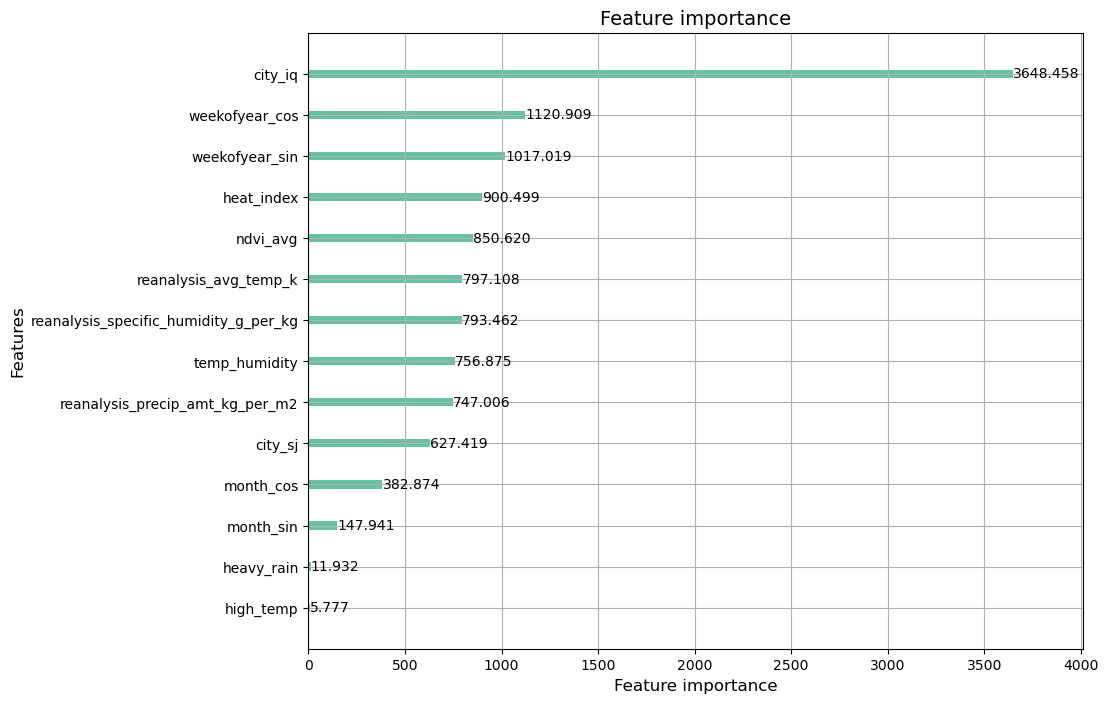

In [157]:
# Feature importance plot
lgb.plot_importance(model, importance_type="gain", figsize=(10, 8));


We couldn't beat the baseline model, so we will move on to a different model (SARIMAX + XGBoost).

### New Model Training

##### Feature selection

In [179]:
features = [
    # Temporal
    'weekofyear_sin', 'weekofyear_cos', 'month_sin', 'month_cos',
    # Lagged Target (now available!)
    'total_cases_lag_1', 'total_cases_lag_4',  
    # Climate
    'reanalysis_specific_humidity_g_per_kg', 'temp_humidity', 'heat_index',
    # NDVI
    'ndvi_avg',  
    # Extreme Events
    'heavy_rain', 'high_temp',
    # City
    'city_iq', 'city_sj'
]

In [180]:
tscv = TimeSeriesSplit(n_splits=5)
for train_idx, val_idx in tscv.split(df):
    train = df.iloc[train_idx]
    val = df.iloc[val_idx]
    
    # Train XGBoost
    model = xgb.XGBRegressor(
        objective='reg:absoluteerror',  # MAE loss
        n_estimators=500,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8
    )
    model.fit(train[features], train['total_cases'])
    
    # Validate
    val_preds = model.predict(val[features])
    mae = mean_absolute_error(val['total_cases'], val_preds)
    print(f"Fold MAE: {mae:.2f}")

Fold MAE: 4.93
Fold MAE: 13.62
Fold MAE: 23.41
Fold MAE: 5.33
Fold MAE: 7.09


#### Hyperparameter tuning

In [182]:
# Tuning
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 100, 1000),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
    }
    
    model = xgb.XGBRegressor(**params, objective='reg:absoluteerror')
    model.fit(train[features], train['total_cases'])
    val_preds = model.predict(val[features])
    return mean_absolute_error(val['total_cases'], val_preds)

study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=30)
print(f"Best params: {study.best_params}")

[I 2025-05-15 15:05:25,968] A new study created in memory with name: no-name-50803bf0-1278-4c07-8d8b-6cf5a9aa815a
[I 2025-05-15 15:05:26,353] Trial 0 finished with value: 7.139813423156738 and parameters: {'n_estimators': 428, 'max_depth': 3, 'learning_rate': 0.11262943241871733, 'subsample': 0.6629088288492211, 'colsample_bytree': 0.6058879766967186}. Best is trial 0 with value: 7.139813423156738.
[I 2025-05-15 15:05:26,993] Trial 1 finished with value: 7.2268967628479 and parameters: {'n_estimators': 564, 'max_depth': 4, 'learning_rate': 0.08049330026364919, 'subsample': 0.7057290465336978, 'colsample_bytree': 0.6379935109230257}. Best is trial 0 with value: 7.139813423156738.
[I 2025-05-15 15:05:28,875] Trial 2 finished with value: 7.285258769989014 and parameters: {'n_estimators': 792, 'max_depth': 7, 'learning_rate': 0.10492315031662329, 'subsample': 0.866299327551074, 'colsample_bytree': 0.9587482330550308}. Best is trial 0 with value: 7.139813423156738.
[I 2025-05-15 15:05:29,78

Best params: {'n_estimators': 126, 'max_depth': 6, 'learning_rate': 0.017362223257950227, 'subsample': 0.968439361099117, 'colsample_bytree': 0.9448565569489517}


In [183]:
best_par = study.best_params
print(f"Best params: {best_par}")
print(f"Best MAE: {study.best_value}")

Best params: {'n_estimators': 126, 'max_depth': 6, 'learning_rate': 0.017362223257950227, 'subsample': 0.968439361099117, 'colsample_bytree': 0.9448565569489517}
Best MAE: 6.542147636413574


#### Finaal Model

In [184]:
# best_params = {
#     'n_estimators': 126,
#     'max_depth': 6,
#     'learning_rate': 0.017362223257950227,
#     'subsample': 0.968439361099117,
#     'colsample_bytree': 0.9448565569489517
# }
best_params = study.best_params

final_model = xgb.XGBRegressor(**best_params, objective='reg:absoluteerror')
final_model.fit(df[features], df['total_cases'])

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.9448565569489517, device=None,
             early_stopping_rounds=None, enable_categorical=False,
             eval_metric=None, feature_types=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.017362223257950227, max_bin=None,
             max_cat_threshold=None, max_cat_to_onehot=None,
             max_delta_step=None, max_depth=6, max_leaves=None,
             min_child_weight=None, missing=nan, monotone_constraints=None,
             multi_strategy=None, n_estimators=126, n_jobs=None,
             num_parallel_tree=None, objective='reg:absoluteerror', ...)

In [186]:
# Tuning Validation
val_preds = final_model.predict(val[features])
print(f"MAE: {mean_absolute_error(val['total_cases'], val_preds):.2f}")
print(f"RMSE: {np.sqrt(mean_squared_error(val['total_cases'], val_preds)):.2f}")
print(f"R²: {r2_score(val['total_cases'], val_preds):.2f}")

MAE: 4.88
RMSE: 9.84
R²: 0.88


<Axes: title={'center': 'Feature importance'}, xlabel='F score', ylabel='Features'>

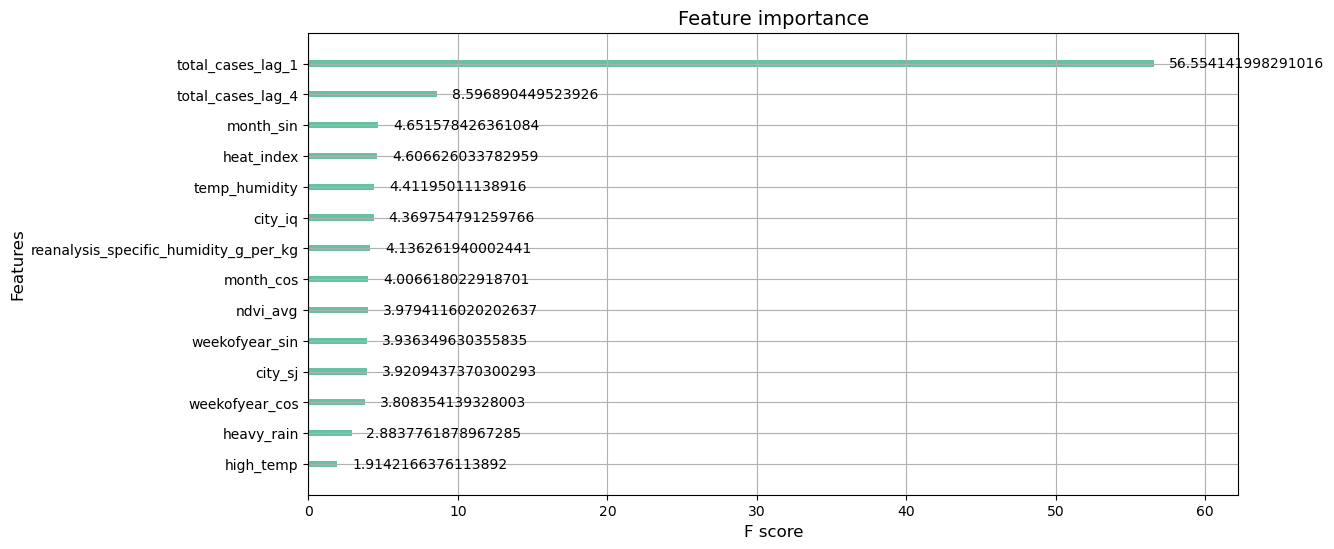

In [187]:
# plot feature importance
xgb.plot_importance(final_model, importance_type="gain")